___
# <center> Análise Exploratória de Dados (EDA) **Avançada**
___

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlexChequer/notebooks-insperai/blob/main/ml-avancado/aula-01-eda-avancada.ipynb)

**Trilha de ML/DL Avançado — InsperAI** · o par prático da [Aula 1](https://trilhas-insperai.vercel.app/ml-avancado/aulas/aula-01/)

## Aula 01 — Trilha de Machine Learning e Deep Learning Avançado

**Objetivo da aula:** ir além do `.describe()` — ao fim desta aula, você será capaz de auditar a qualidade de uma base, diagnosticar assimetria e outliers com mais de uma técnica, medir associação entre variáveis de **qualquer tipo**, entender os mecanismos de dados faltantes, detectar diferenças de distribuição entre treino e teste, e transformar cada achado em uma **decisão de modelagem**.

---

### Como este notebook está organizado

| Parte | O que é | Quando |
|---|---|---|
| **PARTE 1 — Demonstração** | Todo o código já escrito. Vamos rodar juntos, célula por célula, discutindo cada resultado. | Em aula |
| **PARTE 2 — Atividade** | Outra base de dados (`diamonds`) e perguntas para você responder sozinho. | Em casa |


> **Na Parte 1 você não precisa escrever código** — o objetivo é entender o *porquê* de cada análise. Anote as dúvidas: elas são exatamente o que a Parte 2 vai cobrar.

<div id="indice"></div>

## Índice

### PARTE 1 — Demonstração em aula (base `titanic`)

1. [Introdução](#introducao)
    - [Qual é o objetivo real da EDA?](#objetivo-eda)
    - [Glossário da base `titanic`](#glossario)
    - [Carregando a base e reconhecimento inicial](#abrindo-arquivo)

2. [Sanidade e qualidade dos dados](#sanidade)
    - [Granularidade: o que é uma linha?](#granularidade)
    - [Valores sentinela: o faltante que não aparece no `isna()`](#sentinela)
    - [Consistência de tipos e categorias](#consistencia)

3. [Análise univariada avançada](#univariada)
    - [Assimetria (*skewness*) e curtose](#skew-kurt)
    - [Q-Q plot: enxergando o desvio da normalidade](#qqplot)
    - [Testes de normalidade e o problema do *n* grande](#normalidade)
    - [O mito da normalidade das *features*](#mito-normalidade)
    - [Transformações: log, Box-Cox e Yeo-Johnson](#transformacoes)

4. [Dados faltantes](#faltantes)
    - [Quantificando e visualizando o padrão](#padrao-faltantes)
    - [MCAR, MAR e MNAR](#mcar-mar-mnar)
    - [Diagnosticando o mecanismo na prática](#diagnostico-faltantes)
    - [A ausência como informação](#indicadora)

5. [Análise bivariada e multivariada](#bivariada)
    - [Correlação: Pearson, Spearman e Kendall](#correlacao)
    - [E quando a variável é categórica?](#categoricas)
    - [Correlação **não** implica causalidade](#causalidade)
    - [O paradoxo de Simpson](#simpson)
    - [*Pairplots*](#pairplot)

6. [Detecção de outliers](#outliers)
    - [Outlier de quê? Três coisas diferentes](#tipos-outlier)
    - [Z-score e Z-score robusto](#zscore)
    - [IQR](#iqr)
    - [Isolation Forest: outliers multivariados](#isolation)
    - [O impacto depende do modelo](#impacto-modelo)

7. [A variável-alvo](#alvo)

8. [Treino × teste: distribuições e *drift*](#drift)
    - [*Adversarial validation*](#adversarial)

9. [Ferramentas que automatizam parte da EDA](#ferramentas)

10. [Do achado à decisão](#decisao)

### PARTE 2 — Atividade para casa (base `diamonds`)

11. [Instruções e glossário](#atividade)
    - [Questão 1 — Sanidade da base](#q1)
    - [Questão 2 — Univariada e transformações](#q2)
    - [Questão 3 — O faltante disfarçado](#q3)
    - [Questão 4 — Associação entre variáveis](#q4)
    - [Questão 5 — Paradoxo de Simpson](#q5)
    - [Questão 6 — Outliers](#q6)
    - [Questão 7 — A variável-alvo](#q7)
    - [Questão 8 — Treino × teste](#q8)
    - [Questão 9 — Do achado à decisão (entrega final)](#q9)

12. [Resumo dos comandos](#resumo-comandos)

13. [Materiais de apoio](#videos)

___
# <center> PARTE 1 — DEMONSTRAÇÃO EM AULA
___

Nesta parte o código já está pronto. Vamos executar em conjunto e **discutir cada saída**. A pergunta que guia tudo é sempre a mesma: *o que este resultado me faz decidir diferente na modelagem?*

___
<div id="introducao"></div>

## 1. Introdução

<div id="objetivo-eda"></div>

### Qual é o objetivo real da EDA?

EDA (*Exploratory Data Analysis*) **não** é rodar `.describe()` e fazer uns gráficos. É o processo de responder **três perguntas** antes de qualquer modelagem:

1. **Os dados são o que dizem ser?** — granularidade, integridade, unidades, período coberto;
2. **O que os dados permitem prever?** — onde está o sinal e quão forte ele é; e
3. **O que vai dar errado depois?** — vazamentos, mudanças de distribuição, variáveis que não existirão em produção.

A terceira pergunta é o que separa EDA básica de EDA **avançada**. Modelos que funcionam no notebook e falham em produção quase sempre falham por algo que estava visível nos dados desde o começo.

> **Regra que vale para a aula inteira:** *EDA gera hipóteses, não conclusões.* Nós olhamos dezenas de gráficos e testamos dezenas de relações sem nenhuma correção estatística para tantas comparações. Logo, todo padrão empolgante que encontrarmos aqui é uma **hipótese a validar** na Aula 2 — nunca um achado estabelecido.

<div id="glossario"></div>

### Glossário da base `titanic`

Cada linha representa um passageiro do navio.

- **survived**: sobreviveu? `0`=não; `1`=sim;
- **pclass**: classe do bilhete: `1`=primeira; `2`=segunda; `3`=terceira;
- **sex**: sexo do passageiro (`male` ou `female`);
- **age**: idade, em anos;
- **sibsp**: número de irmãos/cônjuges a bordo;
- **parch**: número de pais/filhos a bordo;
- **fare**: tarifa paga pelo bilhete, em libras;
- **embarked**: porto de embarque: `C`=Cherbourg; `Q`=Queenstown; `S`=Southampton; e
- **deck**: convés da cabine (`A` a `G`).

**Por que essa base?** É pequena, real, e tem exatamente os problemas que queremos estudar: variável fortemente assimétrica (`fare`), outliers, e dados faltantes com **causas diferentes** (`age`, `deck`, `embarked`).

In [1]:
# Bibliotecas usadas em toda a Parte 1
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import median_abs_deviation

from sklearn.ensemble import IsolationForest, HistGradientBoostingClassifier
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style='whitegrid')
pd.set_option('display.width', 200)

<div id="abrindo-arquivo"></div>

### Carregando a base e reconhecimento inicial

O comando a seguir carrega a base `titanic`: da pasta `dados/` quando você está rodando local, e direto do GitHub deste repositório quando está no Colab.

In [2]:
CANDIDATOS = ["dados/titanic.csv", "../dados/titanic.csv"]
URL = "https://raw.githubusercontent.com/AlexChequer/notebooks-insperai/main/dados/titanic.csv"

dados = pd.read_csv(next((c for c in CANDIDATOS if os.path.exists(c)), URL))

print(f'Base carregada: {dados.shape[0]} linhas e {dados.shape[1]} colunas.')

Base carregada: 891 linhas e 15 colunas.


In [3]:
dados.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
dados.dtypes

survived         int64
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
class              str
who                str
adult_male        bool
deck               str
embark_town        str
alive              str
alone             bool
dtype: object

In [5]:
dados.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


...<p>
O `.describe()` é o **ponto de partida** — mas repare em tudo o que ele **não** conta: não diz se a distribuição é assimétrica, não aponta outliers, não explica por que `age` tem menos observações que as demais colunas, e não mostra nenhuma das colunas categóricas. <br>
É exatamente esse o vazio que a EDA avançada preenche.

[Voltar ao Índice](#indice)

___
<div id="sanidade"></div>

## 2. Sanidade e qualidade dos dados

Esta seção vem **antes** da estatística descritiva, e a ordem não é negociável: a assimetria de uma coluna que na verdade mistura duas unidades de medida não significa nada. <br>
Primeiro entendemos o que é uma linha e se os valores são válidos. Só então descrevemos distribuições.

<div id="granularidade"></div>

### Granularidade: o que é uma linha?

A primeira pergunta de qualquer base é: **uma linha representa o quê?** Um cliente? Um cliente-mês? Uma transação? <br>
Isso não é burocracia — determina a estratégia de validação (Aula 2), o significado de toda média, e até o que conta como duplicata.

In [6]:
print(f'Linhas: {dados.shape[0]}')
print(f'Linhas duplicadas (idênticas em todas as colunas): {dados.duplicated().sum()}')

# Existe alguma coluna que poderia ser a chave (identificador único)?
for coluna in dados.columns:
    n_unicos = dados[coluna].nunique()
    if n_unicos > 0.9 * len(dados):
        print(f'  -> {coluna}: {n_unicos} valores únicos (candidata a identificador)')

Linhas: 891
Linhas duplicadas (idênticas em todas as colunas): 107


...<p>
Nenhuma coluna é identificador único, e existem linhas idênticas. <br>
**Isso é um problema?** Aqui, não: dois passageiros de 3ª classe, homens, mesma idade e mesma tarifa são plausivelmente pessoas diferentes. <br>
**Reflita/discuta:** se essa base fosse de *transações bancárias*, duas linhas idênticas seriam duplicata ou duas compras legítimas iguais? <br>
A resposta depende de saber qual é a chave — e isso é conhecimento de negócio, não de estatística.

<div id="sentinela"></div>

### Valores sentinela: o faltante que não aparece no `isna()`

Este é, na prática, o problema de qualidade mais perigoso — porque é **invisível** numa EDA superficial.

**Um valor sentinela é um valor comum que um sistema usa para significar "não tenho esse dado", em vez de deixar o campo realmente vazio.**

Sistemas legados frequentemente codificam ausência com valores *válidos* do tipo da coluna: `-999`, `-1`, `9999`, `0`, datas como `1900-01-01`, textos como `"NA"`, `"N/A"`, `"-"`, `"desconhecido"`. <br>
**Nenhum deles aparece em `df.isna().sum()`.**

Vamos simular exatamente isso na base do Titanic para ver o estrago:

In [7]:
# SIMULAÇÃO: criamos uma cópia da base onde 12% das idades foram gravadas como -999
# (é assim que muitos sistemas legados codificam 'não informado')
dados_sujos = dados.copy()
indices_sentinela = dados_sujos.sample(frac=0.12, random_state=42).index
dados_sujos.loc[indices_sentinela, 'age'] = -999

print('O isna() enxerga o problema?')
print(f"  Faltantes declarados em 'age': {dados_sujos['age'].isna().sum()}")
print()
print('E o describe()?')
print(dados_sujos['age'].describe().round(2))

O isna() enxerga o problema?
  Faltantes declarados em 'age': 160

E o describe()?
count    731.00
mean    -120.93
std      364.10
min     -999.00
25%       16.00
50%       25.00
75%       36.00
max       80.00
Name: age, dtype: float64


...<p>
O `.isna()` diz que existem menos faltantes do que antes (os `NaN` viraram `-999`). <br>
A **média de idade virou um número negativo** — e, se ninguém olhar, esse número entra silenciosamente no `StandardScaler`, na matriz de correlação e no modelo.

Como caçar sentinelas:

In [8]:
# 1) Os extremos são fisicamente possíveis?
print('Mínimos e máximos das colunas numéricas:')
print(dados_sujos.select_dtypes(include=np.number).agg(['min', 'max']).T)
print()

# 2) Algum valor se repete muito mais do que deveria?
print('Valores mais frequentes de age:')
print(dados_sujos['age'].value_counts().head(5))

Mínimos e máximos das colunas numéricas:
            min       max
survived    0.0    1.0000
pclass      1.0    3.0000
age      -999.0   80.0000
sibsp       0.0    8.0000
parch       0.0    6.0000
fare        0.0  512.3292

Valores mais frequentes de age:
age
-999.0    107
 24.0      28
 22.0      25
 18.0      23
 28.0      22
Name: count, dtype: int64


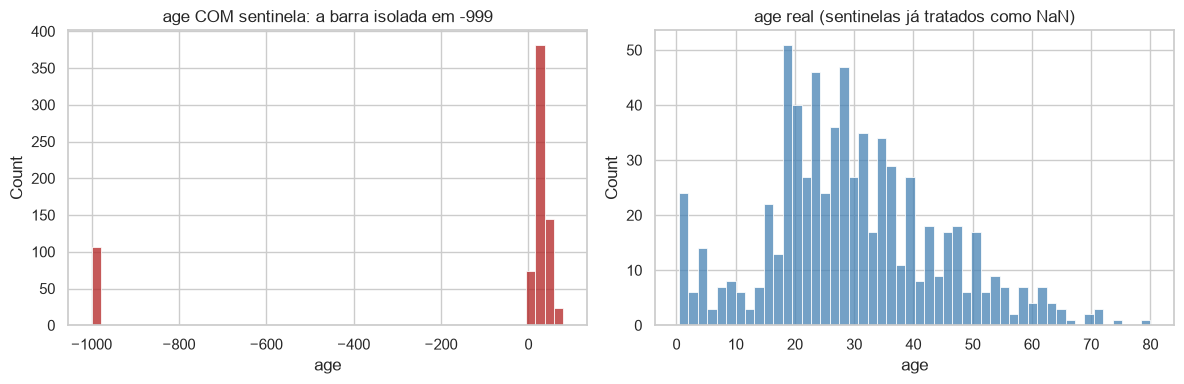

In [9]:
# 3) O histograma denuncia na hora
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(dados_sujos['age'], bins=50, ax=axes[0], color='firebrick')
axes[0].set_title('age COM sentinela: a barra isolada em -999')

sns.histplot(dados['age'].dropna(), bins=50, ax=axes[1], color='steelblue')
axes[1].set_title('age real (sentinelas já tratados como NaN)')

plt.tight_layout()
plt.show()

...<p>
**A lição:** o `.describe()` esconde, o histograma denuncia. Por isso EDA visual não é opcional. <br>
A partir daqui voltamos a usar a base `dados` original — a `dados_sujos` era só a demonstração.

> **Decisão de modelagem:** todo sentinela identificado deve ser convertido para `NaN` **e** ganhar uma coluna indicadora (`age_ausente`), porque o fato de o dado estar ausente costuma ser informativo — voltaremos a isso na seção 4.

<div id="consistencia"></div>

### Consistência de tipos e categorias

Três checagens rápidas que evitam retrabalho:

- **Tipos errados**: CEP, CPF e código de produto lidos como `int` (perdem zeros à esquerda e viram numéricos *ordenáveis*, o que é semanticamente falso);
- **Mesma categoria, grafias diferentes**: `"SP"`, `"S.P."`, `"São Paulo"`, `"sao paulo"` — isso fragmenta o sinal entre categorias que deveriam ser uma só; e
- **Alta cardinalidade**: colunas com quase tantos valores únicos quanto linhas costumam ser identificadores disfarçados de *feature* — e identificador dentro do modelo é uma das formas mais comuns de vazamento.

In [10]:
# Inventário das colunas categóricas: cardinalidade e valores
categoricas = dados.select_dtypes(exclude=np.number).columns

for coluna in categoricas:
    valores = dados[coluna].dropna().unique()
    print(f'{coluna:<12} | {len(valores):>2} categorias | {list(valores)[:8]}')

print('\n--- E as numéricas que têm um "gêmeo" textual? ---\n')

for num, txt in [('survived', 'alive'), ('pclass', 'class')]:
    print(f'{num} x {txt}:')
    print(pd.crosstab(dados[num], dados[txt]))
    print()

sex          |  2 categorias | ['male', 'female']
embarked     |  3 categorias | ['S', 'C', 'Q']
class        |  3 categorias | ['Third', 'First', 'Second']
who          |  3 categorias | ['man', 'woman', 'child']
adult_male   |  2 categorias | [np.True_, np.False_]
deck         |  7 categorias | ['C', 'E', 'G', 'D', 'A', 'B', 'F']
embark_town  |  3 categorias | ['Southampton', 'Cherbourg', 'Queenstown']
alive        |  2 categorias | ['no', 'yes']
alone        |  2 categorias | [np.False_, np.True_]

--- E as numéricas que têm um "gêmeo" textual? ---

survived x alive:
alive      no  yes
survived          
0         549    0
1           0  342

pclass x class:
class   First  Second  Third
pclass                      
1         216       0      0
2           0     184      0
3           0       0    491



...<p>
**Reflita/discuta:** repare que `pclass` e `class` carregam exatamente a mesma informação, assim como `embarked` e `embark_town`, e `survived` e `alive`. <br>
Manter as duas versões de cada par no modelo é redundância pura — e no caso de `survived`/`alive` seria **vazamento perfeito do alvo**. <br>
Achar isso na EDA custa 30 segundos; achar isso depois de treinar um modelo com AUC 1.0 custa uma tarde.

[Voltar ao Índice](#indice)

___
<div id="univariada"></div>

## 3. Análise univariada avançada

<div id="skew-kurt"></div>

### Assimetria (*skewness*) e curtose

**Assimetria (skewness)** mede o quanto a distribuição é puxada para um lado:

- **positiva**: cauda longa à **direita** — poucos valores muito altos (renda, preço, tempo até evento);
- **negativa**: cauda longa à **esquerda**; e
- **próxima de 0**: aproximadamente simétrica.

Convenções de leitura: entre $-0{,}5$ e $+0{,}5$ é aproximadamente simétrica; entre $0{,}5$ e $1$ (em módulo) a assimetria é moderada; acima de $1$ ela é forte o bastante para que **a média deixe de ser um resumo honesto** da variável.

**Curtose** mede o peso das caudas — quantos valores extremos existem além do que uma normal produziria.

Skewness pergunta de que lado estão os extremos, é sobre sua **direção**, já curtose pergunta quantos existem, em qualquer lado, é sobre sua **intensidade**.

> **Atenção à notação:** `pandas` e `scipy` retornam o **excesso de curtose** por padrão (normal = 0), não a curtose bruta (normal = 3). É daí que nasce a confusão quando alguém compara com um valor de livro.

In [11]:
for coluna in ['fare', 'age']:
    serie = dados[coluna].dropna()
    print(f'{coluna:>5} | skewness = {serie.skew():>6.2f} | excesso de curtose = {serie.kurtosis():>6.2f}')

 fare | skewness =   4.79 | excesso de curtose =  33.40
  age | skewness =   0.39 | excesso de curtose =   0.18


Os dois números medem **formato** da distribuição — coisa que a média e o desvio-padrão não contam.

**Lendo a assimetria.** O jeito mais concreto de enxergá-la é comparar média e mediana:

| | média | mediana | máximo |
|---|---|---|---|
| `fare` | 32,20 | **14,45** | 512,33 |
| `age` | 29,70 | **28,00** | 80,00 |

Em `age`, média e mediana quase coincidem — distribuição equilibrada, e a skewness de 0,39 confirma.

Em `fare`, a média é **mais que o dobro** da mediana. Metade dos passageiros pagou menos de 15 libras, mas a média diz 32. Um punhado de pessoas pagou 200, 300, 512 libras, e esses valores puxam a média sozinhos.

> **A consequência:** se alguém perguntar "quanto custava um bilhete do Titanic?", responder "32 libras" está tecnicamente certo e praticamente errado — esse valor não descreve quase ninguém. Com assimetria forte, **a média deixa de ser um resumo honesto**.

**Lendo a curtose.** A pergunta que ela responde é diferente: *os valores extremos são mais frequentes do que o desvio-padrão sugeriria?*

`age` deu 0,18 — comportamento praticamente normal. `fare` deu **33,40**, o que não é "um pouco acima", é outro patamar. A tarifa de 512 libras está a mais de **nove desvios-padrão** da média; sob normalidade, algo assim não deveria ser observado em 891 pessoas. E há três casos.

In [12]:
# Duas distribuições com MESMA média e MESMO desvio-padrão.
# O que muda é só o peso das caudas.
n_demo = 200_000

normal = stats.norm.rvs(size=n_demo, random_state=1)
cauda_pesada = stats.t.rvs(df=3, size=n_demo, random_state=1)
cauda_pesada = cauda_pesada / cauda_pesada.std() * normal.std()   # igualamos o desvio

print(f"{'distribuição':>14} | {'média':>7} | {'desvio':>7} | {'curtose':>8} | {'% além de 3 dp':>14} | {'máximo':>7}")
print('-' * 80)
for nome, x in [('normal', normal), ('cauda pesada', cauda_pesada)]:
    z = (x - x.mean()) / x.std()
    print(f'{nome:>14} | {x.mean():>7.3f} | {x.std():>7.3f} | {pd.Series(x).kurtosis():>8.2f} | '
          f'{(np.abs(z) > 3).mean():>13.2%} | {np.abs(x).max():>7.1f}')

  distribuição |   média |  desvio |  curtose | % além de 3 dp |  máximo
--------------------------------------------------------------------------------
        normal |   0.004 |   0.998 |     0.00 |         0.28% |     4.4
  cauda pesada |   0.001 |   0.998 |    55.57 |         1.46% |    43.2


Média igual, desvio-padrão igual. Pelo `.describe()`, as duas seriam intercambiáveis.

Mas a de cauda pesada produz eventos além de 3 desvios **cinco vezes mais** que a normal, e seu valor mais extremo é dez vezes maior. Toda essa diferença está capturada num único número: a curtose.

> **O insight:** curtose mede o quanto o desvio-padrão está **subestimando** o risco de eventos extremos. Quanto maior ela, menos o "comportamento típico" descreve o que pode acontecer.

Repare que assimetria e curtose respondem perguntas diferentes: skewness pergunta *para que lado* a distribuição pende; curtose pergunta *quão frequentes são os extremos*, independentemente do lado. Uma distribuição pode ser perfeitamente simétrica e ter caudas monstruosas — é o caso da segunda linha da tabela acima.

**Onde isso morde:** detecção de outliers (o corte |Z| > 3 foi calibrado para marcar 0,3% e vai marcar muito mais), risco financeiro (retornos de ações têm curtose alta, e quem dimensiona perda assumindo normalidade subestima crashes), e estabilidade de modelos com erro quadrático (um único ponto de cauda domina o ajuste).

> **Mito a desfazer:** curtose **não** mede o quão "pontuda" é a distribuição. Essa era a interpretação dos livros-texto antigos e está errada — ela mede **peso de cauda**. As duas distribuições acima têm picos parecidos; o que as separa está nas pontas.

...<p>
`fare` tem assimetria em outro patamar. Uma assimetria dessas merece ser **vista**:

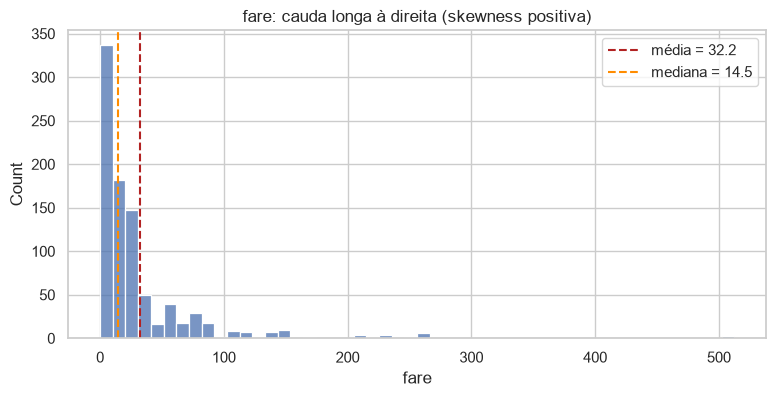

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=dados, x='fare', bins=50, ax=ax)
ax.axvline(dados['fare'].mean(), color='firebrick', linestyle='--',
           label=f"média = {dados['fare'].mean():.1f}")
ax.axvline(dados['fare'].median(), color='darkorange', linestyle='--',
           label=f"mediana = {dados['fare'].median():.1f}")
ax.set_title('fare: cauda longa à direita (skewness positiva)')
ax.legend()
plt.show()

...<p>
A **média é puxada pela cauda** e fica bem acima da mediana — a assinatura clássica de assimetria positiva. <br>
**Consequência prática:** qualquer método que use média e desvio-padrão (Z-score, padronização, distância euclidiana) herda essa distorção.

<div id="qqplot"></div>

### Q-Q plot: enxergando *como* a distribuição desvia da referência

O Q-Q plot compara os quantis observados com os quantis teóricos de uma **distribuição de referência** — que você escolhe. Se os pontos caem sobre a reta, a sua distribuição se parece com a referência.

Aqui usamos a normal (`dist='norm'`), porque é a referência que os métodos clássicos assumem. Mas repare que ela é um **parâmetro**, não parte da definição: `dist='lognorm'`, `dist='expon'` e `dist='gamma'` são igualmente válidos, e testar outras referências é como se descobre *qual* transformação a variável pede.

A vantagem sobre um teste estatístico é que ele mostra **onde** e **como** o desvio acontece — informação que nenhum p-valor entrega.

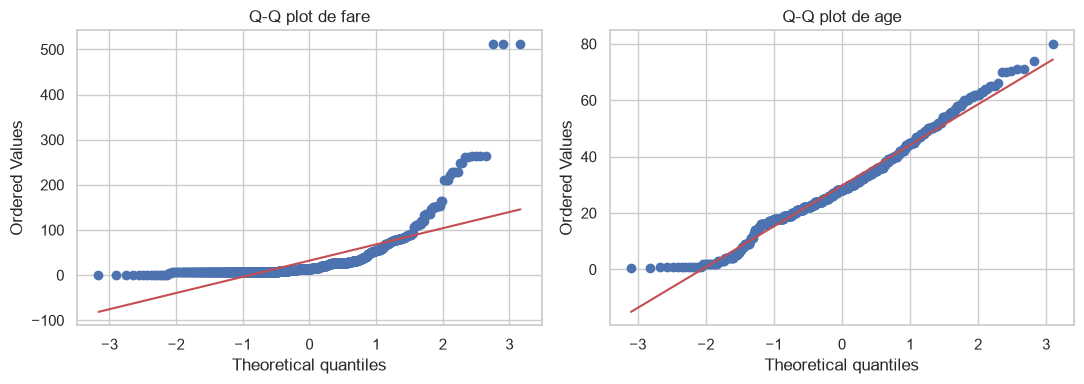

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

stats.probplot(dados['fare'].dropna(), dist='norm', plot=axes[0])
axes[0].set_title('Q-Q plot de fare')

stats.probplot(dados['age'].dropna(), dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot de age')

plt.tight_layout()
plt.show()

...<p>
Leitura dos dois gráficos: `fare` sobe abruptamente acima da reta na ponta direita — **cauda pesada à direita**. `age` acompanha a reta em quase toda a extensão e só se afasta discretamente nas pontas. <br>
Isso é informação que nenhum p-valor entrega.

In [15]:
# O Q-Q plot não é um teste de normalidade — a referência é escolha sua.
# Qual distribuição descreve melhor a tarifa?
fare_positivo = dados.loc[dados['fare'] > 0, 'fare']

print('R² do ajuste à reta (1.0 = ajuste perfeito à referência):\n')
for nome, dist, args in [
    ('normal',      'norm',    ()),
    ('lognormal',   'lognorm', (stats.lognorm.fit(fare_positivo, floc=0)[0],)),
    ('exponencial', 'expon',   ()),
    ('gamma',       'gamma',   (stats.gamma.fit(fare_positivo, floc=0)[0],)),
]:
    _, (_, _, r) = stats.probplot(fare_positivo, dist=dist, sparams=args)
    print(f'  {nome:>12}: R² = {r**2:.4f}')

R² do ajuste à reta (1.0 = ajuste perfeito à referência):

        normal: R² = 0.5154
     lognormal: R² = 0.9595
   exponencial: R² = 0.8483
         gamma: R² = 0.8425


Contra a normal, `fare` tem R² de 0,52 — péssimo ajuste, como os gráficos já mostraram. Contra a **lognormal**, 0,96.

Isso não é curiosidade: é um achado com consequência direta. Se `fare` é aproximadamente lognormal, então `log(fare)` é aproximadamente normal — e é exatamente por isso que a transformação log funciona tão bem nessa variável (você vai ver na seção 3.5, quando a skewness cair de 4,79 para 0,44).

> **A ferramenta não disse apenas que a variável era torta — disse qual transformação usar.**

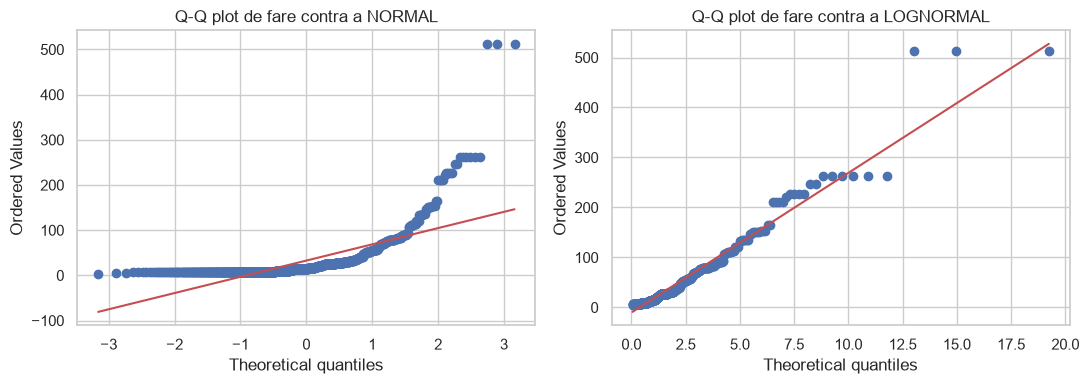

In [16]:
fare_positivo = dados.loc[dados['fare'] > 0, 'fare']      # lognormal não aceita zeros
s, _, _ = stats.lognorm.fit(fare_positivo, floc=0)        # estima o parâmetro de forma

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

stats.probplot(fare_positivo, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q plot de fare contra a NORMAL')

stats.probplot(fare_positivo, dist='lognorm', sparams=(s,), plot=axes[1])
axes[1].set_title('Q-Q plot de fare contra a LOGNORMAL')

plt.tight_layout()
plt.show()

<div id="normalidade"></div>

### Testes de normalidade e o problema do *n* grande

No teste de **Shapiro-Wilk**, a hipótese nula é *"os dados vêm de uma distribuição normal"*. Um p-valor pequeno indica evidência **contra** a normalidade.

In [17]:
for coluna in ['fare', 'age']:
    estatistica, p_valor = stats.shapiro(dados[coluna].dropna())
    veredito = 'NÃO é normal' if p_valor < 0.05 else 'não rejeitamos normalidade'
    print(f'{coluna:>5} | W = {estatistica:.4f} | p = {p_valor:.2e} -> {veredito}')

 fare | W = 0.5219 | p = 1.08e-43 -> NÃO é normal
  age | W = 0.9815 | p = 7.34e-08 -> NÃO é normal


Os dois rejeitam. Mas repare na estatística **W**, que o p-valor faz a gente ignorar:

O **W mede *quão perto* da normal a distribuição está**, numa escala em que 1 é normalidade perfeita. `fare` está em 0,52 — longíssimo. `age` está em 0,98 — praticamente colado no 1.

Os dois recebem o mesmo carimbo, mas um está a um passo e o outro a um quilômetro. **O p-valor não distingue os dois casos; o W distingue.**

E por que `age` rejeita, estando tão perto? Porque com 714 observações o teste tem poder de sobra para detectar desvios minúsculos. Existe um desvio real ali — vamos medi-lo:

...<p>
Os dois rejeitam. Mas aqui vem o ponto que quase nenhum curso ensina: **o poder do teste cresce com o tamanho da amostra**. <br>
Vamos provar isso. O experimento abaixo usa uma **única população**, com um desvio *minúsculo* da normalidade (skewness ≈ 0,2), e só varia o `n` da amostra:

In [18]:
# Uma população fixa, levemente assimétrica (o desvio é sempre o mesmo)
populacao = stats.skewnorm.rvs(a=1.2, size=200_000, random_state=1)
print(f'Skewness da população: {pd.Series(populacao).skew():.3f}  (desvio pequeno e IRRELEVANTE na prática)')
print()

gerador = np.random.default_rng(0)
print(f"{'n':>6} | {'skewness':>9} | {'p-valor':>10} | conclusão do teste")
print('-' * 58)
for n in [30, 100, 500, 2000, 5000]:
    amostra = gerador.choice(populacao, n, replace=False)
    p = stats.shapiro(amostra).pvalue
    conclusao = 'rejeita normalidade' if p < 0.05 else 'não rejeita'
    print(f'{n:>6} | {pd.Series(amostra).skew():>+9.3f} | {p:>10.1e} | {conclusao}')

Skewness da população: 0.201  (desvio pequeno e IRRELEVANTE na prática)

     n |  skewness |    p-valor | conclusão do teste
----------------------------------------------------------
    30 |    +0.875 |    1.9e-01 | não rejeita
   100 |    +0.495 |    1.9e-01 | não rejeita
   500 |    +0.168 |    8.8e-02 | não rejeita
  2000 |    +0.271 |    6.4e-06 | rejeita normalidade
  5000 |    +0.119 |    7.8e-04 | rejeita normalidade


**Mas por que o `n` influencia?** A questão é **distinguir sinal de ruído**.

Pense no problema que o teste enfrenta. Ele olha uma amostra torta e precisa escolher entre duas explicações:

1. A população é normal, e essa amostra saiu torta **por azar do sorteio**;
2. A população realmente é torta.

Com amostra pequena, a explicação (1) é perfeitamente plausível — sorteios pequenos variam muito. Com amostra grande, ela deixa de ser: sorteios grandes não saem tortos por acaso.

Dá para **medir esse ruído** diretamente:

In [19]:
# Sorteamos de uma população PERFEITAMENTE normal (skewness verdadeira = 0).
# Quanto a skewness da amostra varia só por acaso?
pop_normal = stats.norm.rvs(size=200_000, random_state=1)
gerador_ruido = np.random.default_rng(0)

print(f"{'n':>6} | {'faixa típica da skewness amostral':>36}")
print('-' * 46)
for n in [30, 100, 500, 2000, 5000]:
    skews = [pd.Series(gerador_ruido.choice(pop_normal, n, replace=False)).skew()
             for _ in range(1000)]
    baixo, alto = np.percentile(skews, [2.5, 97.5])
    print(f'{n:>6} |   de {baixo:+.3f} a {alto:+.3f}   (amplitude {alto - baixo:.3f})')

     n |    faixa típica da skewness amostral
----------------------------------------------
    30 |   de -0.854 a +0.845   (amplitude 1.700)
   100 |   de -0.509 a +0.513   (amplitude 1.022)
   500 |   de -0.204 a +0.207   (amplitude 0.411)


  2000 |   de -0.102 a +0.118   (amplitude 0.220)


  5000 |   de -0.065 a +0.069   (amplitude 0.134)


Esta tabela é a resposta. A população aqui é **perfeitamente normal** — skewness verdadeira igual a zero. Mesmo assim, amostras dela saem tortas por puro acaso, e a magnitude desse acaso depende do `n`.

Agora compare com a população do experimento anterior, que tem skewness real de **0,201**:

- **Com n = 30**, o ruído vai de −0,85 a +0,85. Um desvio de 0,20 está confortavelmente dentro do que o acaso produz. O teste não consegue separar — e não rejeita.
- **Com n = 5000**, o ruído vai de −0,065 a +0,069. Um desvio de 0,20 está **três vezes fora** dessa faixa. O acaso não explica mais; o teste rejeita.

**O desvio real nunca mudou. O que encolheu foi a régua do acaso** — e por isso o mesmo desvio passou de invisível a gritante.

> **A analogia:** uma moeda que dá cara 51% das vezes. Com 10 lançamentos, você não tem como saber — 6 caras acontecem o tempo todo com moeda honesta. Com 10 mil lançamentos, 5.100 caras é evidência esmagadora. A moeda é a mesma; o que muda é sua capacidade de detectar um viés minúsculo.

**A consequência:** o teste de normalidade não responde *"o desvio é grande?"*. Ele responde *"o desvio é detectável com o `n` que eu tenho?"*. Com dezenas de milhares de linhas — o normal em ML — tudo é detectável, e o teste rejeita sempre.

Por isso a decisão volta para o **Q-Q plot** e para a **skewness**, que medem **tamanho** do desvio, não detectabilidade.

**A população é sempre a mesma.** O desvio da normalidade é sempre o mesmo e sempre irrelevante. O que muda é apenas o tamanho da amostra — e a conclusão do teste **se inverte**.

Ou seja: com dados de Machine Learning (dezenas de milhares de linhas), o teste de normalidade responde na prática à pergunta *"sua amostra é grande?"*, e não *"sua variável é normal?"*.

> **O que fazer no lugar:** olhar. Histograma, densidade e sobretudo o **Q-Q plot**, combinados com skewness e curtose como *medidas de tamanho do efeito*. A pergunta prática nunca é "é normal?", é **"o desvio é grande o suficiente para afetar a decisão que vou tomar?"**.

**O que usar no lugar**

**Por que abandonar o teste (nesse contexto).** Ele responde *"esse desvio é detectável com o `n` que eu tenho?"*. Como em ML você quase sempre tem muitas linhas, ele vai rejeitar praticamente sempre — e uma ferramenta que dá a mesma resposta em todos os casos não ajuda a decidir nada.

> Isso **não** significa que o teste seja inútil. Em amostras pequenas (experimento de laboratório, validação de instrumento, teste A/B com poucas observações) ele é informativo. O problema é usá-lo onde o `n` grande torna a resposta automática.

**Detectar × medir.** É a distinção central:

- O **p-valor detecta**: diz se o desvio existe, misturando o tamanho real dele com o tamanho da amostra. Por isso infla com `n` grande;
- **Skewness, curtose e W medem**: quantificam o desvio, e não dependem de quantas linhas você tem. São comparáveis entre variáveis e entre bases.

| | p-valor | veredito | W (tamanho do efeito) |
|---|---|---|---|
| `fare` | 1,08e−43 | não é normal | **0,52** |
| `age` | 7,34e−08 | não é normal | **0,98** |

Pelo p-valor, casos idênticos. Pelo W, um está a um passo da normal e o outro a um quilômetro. **Só a segunda leitura permite tratá-los de forma diferente** — que é o que você precisa fazer.

O **Q-Q plot** acrescenta uma dimensão que nenhum número dá: **onde** o desvio está. `fare` cola na reta no miolo e dispara na ponta direita — logo o problema é a *cauda*, não o centro. Isso muda o tratamento (transformar? usar método robusto? deixar como está?).

**A pergunta é sempre sobre a decisão.** Normalidade não é uma propriedade absoluta da variável — ela só importa *relativa ao que você vai fazer em seguida*:

| Variável | O que vou fazer | O desvio importa? |
|---|---|---|
| `fare` | treinar XGBoost | **Não** — árvores são invariantes a transformação monotônica |
| `fare` | detectar outliers por Z-score | **Sim** — o corte marcou 20 em vez de 2 |
| `fare` | regressão linear com intervalos de confiança | **Sim** — alavancagem dos extremos |
| `age` | detectar outliers por Z-score | **Não** — esperava 1,9, encontrou 2 |

Note que `fare` aparece três vezes com respostas diferentes. **Não é a variável que decide; é o par variável-método.**

> **O algoritmo mental:**
> 1. **Meça** o desvio (skewness, curtose, Q-Q plot) — não teste;
> 2. Pergunte **qual método** vai consumir essa variável;
> 3. Pergunte se aquele método é **sensível a esse tipo** de desvio;
> 4. Só transforme se (2) e (3) pedirem.

O passo 4 é o que salva tempo. Muita gente transforma tudo por reflexo, e no caso mais comum em dados tabulares — modelos de árvore — isso não muda absolutamente nada.

<div id="mito-normalidade"></div>

### O mito da normalidade das *features*

Você vai encontrar em muitos cursos a afirmação de que *modelos lineares exigem features com distribuição normal*. **Isso está errado.**

A regressão linear não assume normalidade das *features*, nem do alvo. A suposição de normalidade da regressão linear clássica é sobre os **resíduos**, e serve para validar **inferência** (intervalos de confiança e testes sobre os coeficientes). Para predição pura, nem essa suposição é estritamente necessária.

**Então por que transformamos variáveis enviesadas?** Por motivos reais, mas outros:

- **Reduzir alavancagem** — poucos pontos extremos dominam a estimativa por mínimos quadrados;
- **Linearizar relações multiplicativas** — se dobrar a renda tem efeito parecido em qualquer faixa, o log torna essa relação aditiva;
- **Estabilizar variância** — quando a dispersão do erro cresce junto com o nível da variável; e
- **Métodos baseados em distância e gradiente** (KNN, SVM, redes) sofrem com escalas dominadas por outliers.

E, crucialmente: **modelos de árvore são invariantes a transformações monotônicas**. Vamos verificar isso empiricamente:

### O que significa "transformar" uma variável

Você acabou de descobrir que `fare` é fortemente assimétrica. A pergunta natural é: *preciso consertar isso antes de modelar?*

Antes de responder, três conceitos.

**Transformar** é aplicar uma função a todos os valores, mudando a escala mas **preservando a ordem** — quem pagou mais continua pagando mais.

**Log.** O logaritmo comprime valores grandes muito mais do que os pequenos:

| tarifa | `log1p(tarifa)` |
|---|---|
| 7 | 2,08 |
| 30 | 3,43 |
| 100 | 4,62 |
| 512 | 6,24 |

Repare no efeito: no mundo original, a distância entre 100 e 512 é enorme (412). Depois do log, vira 1,6 — **menor** que a distância entre 7 e 30. A cauda longa foi esmagada e a distribuição fica quase simétrica.

> Usamos `log1p`, que calcula $\log(1+x)$, porque $\log(0)$ não existe e há tarifas zeradas na base.

**Box-Cox.** O log é uma escolha fixa. O Box-Cox é uma **família** de transformações controlada por um parâmetro $\lambda$, e o método encontra automaticamente o $\lambda$ que melhor simetriza *aquela* variável — você não precisa adivinhar se o certo é log, raiz quadrada ou outra coisa. O log é o caso particular $\lambda = 0$.

**AUC.** É uma nota de 0 a 1 que mede quão bem o modelo separa quem sobreviveu de quem não sobreviveu: 0,5 é chute aleatório, 1,0 é perfeito.

> **AUC é conteúdo da Aula 2.** Aqui ela aparece só como *termômetro* — você não precisa saber como é calculada para ler o resultado abaixo. Basta notar se o número **muda ou não muda**.

Com isso na mão, o teste: três versões da mesma variável, o mesmo modelo, e vamos ver se o resultado se altera.

In [20]:
colunas = ['pclass', 'fare', 'sibsp', 'parch']
alvo = dados['survived']
arvore = DecisionTreeClassifier(max_depth=4, random_state=0)

X_original = dados[colunas].copy()

X_log = X_original.copy()
X_log['fare'] = np.log1p(X_log['fare'])

X_boxcox = X_original.copy()
X_boxcox['fare'] = stats.boxcox(X_boxcox['fare'] + 1)[0]

for nome, X in [('fare original', X_original), ('log1p(fare)', X_log), ('Box-Cox(fare)', X_boxcox)]:
    auc = cross_val_score(arvore, X, alvo, cv=5, scoring='roc_auc').mean()
    print(f'{nome:>15} | AUC = {auc:.6f}')

  fare original | AUC = 0.732351
    log1p(fare) | AUC = 0.731633
  Box-Cox(fare) | AUC = 0.731633


Log e Box-Cox produzem AUC **idêntico até a sexta casa decimal**, e praticamente igual ao original (a diferença na quarta casa é ruído de desempate), a árvore não percebeu que você transformou a variável.

**Por que isso acontece.** A árvore de decisão funciona fazendo perguntas do tipo *"a tarifa é maior que 30?"* e separando os passageiros em dois grupos. O que importa para ela é **quem fica de cada lado**.

Depois do log, o mesmo corte vira *"a tarifa é maior que 3,43?"* — número diferente, **exatamente as mesmas pessoas** de cada lado. Como a transformação preserva a ordem, nenhuma separação possível muda. A árvore, na prática, nem percebe que você transformou.

E o Box-Cox? Ele encontrou $\lambda$ próximo de zero, ou seja, **descobriu sozinho que o log era a resposta** para essa variável.

**E os outros modelos?** Aí a história muda. Regressão logística multiplica coeficientes, redes neurais somam entradas, KNN calcula distâncias — todos fazem **contas** com os valores, e para eles a magnitude importa, não só a ordem.

> **Decisão de modelagem:** se o destino é XGBoost/LightGBM/Random Forest, transformar variáveis assimétricas é trabalho perdido. Se o destino é regressão logística ou uma rede neural, é essencial.

Ou seja: a assimetria de `fare` é um fato sobre os dados, mas **só vira um problema quando combinada com um modelo que se importa com ela**. Meça sempre; corrija apenas quando o método pedir.

<div id="transformacoes"></div>

### Transformações: log, Box-Cox e Yeo-Johnson

| Transformação | Domínio | Quando usar |
|---|---|---|
| `log` / `log1p` | $x > 0$ (o `log1p` aceita $x \ge 0$) | Relação multiplicativa, cauda longa. Interpretável: o coeficiente vira efeito percentual aproximado |
| Box-Cox | $x$ estritamente positivo | Busca automaticamente o expoente $\lambda$ que melhor simetriza. O log é o caso $\lambda = 0$ |
| **Yeo-Johnson** | qualquer real (aceita zeros e negativos) | Mesma ideia do Box-Cox, mas funciona com zero e valores negativos — **o caso mais comum em dados reais** |
| raiz quadrada | $x \ge 0$ | Assimetria leve, dados de contagem |
| *quantile transform* | qualquer | Força a distribuição a ser normal/uniforme. Robusto, mas destrói a escala original |

In [21]:
fare_log = np.log1p(dados['fare'])

# Box-Cox exige valores estritamente positivos, por isso filtramos fare > 0
fare_positivo = dados.loc[dados['fare'] > 0, 'fare']
fare_boxcox, lambda_otimo = stats.boxcox(fare_positivo)

# Yeo-Johnson aceita o zero, então roda na coluna inteira
transformador = PowerTransformer(method='yeo-johnson')
fare_yj = transformador.fit_transform(dados[['fare']]).ravel()

print(f'Skewness original          : {dados["fare"].skew():>6.3f}')
print(f'Skewness após log1p        : {fare_log.skew():>6.3f}')
print(f'Skewness após Box-Cox      : {pd.Series(fare_boxcox).skew():>6.3f}   (lambda = {lambda_otimo:.3f})')
print(f'Skewness após Yeo-Johnson  : {pd.Series(fare_yj).skew():>6.3f}   (lambda = {transformador.lambdas_[0]:.3f})')

Skewness original          :  4.787
Skewness após log1p        :  0.395
Skewness após Box-Cox      :  0.218   (lambda = -0.524)
Skewness após Yeo-Johnson  : -0.040   (lambda = -0.098)


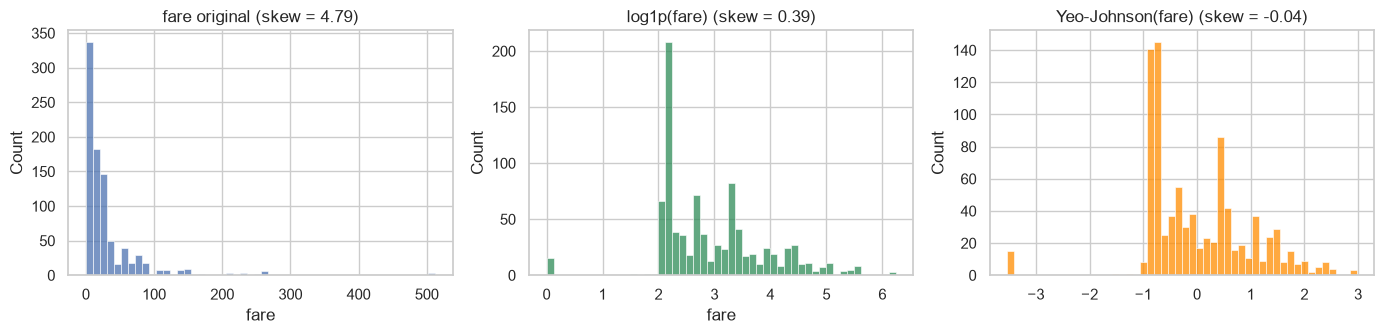

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

sns.histplot(x=dados['fare'], bins=50, ax=axes[0])
axes[0].set_title(f"fare original (skew = {dados['fare'].skew():.2f})")

sns.histplot(x=fare_log, bins=50, ax=axes[1], color='seagreen')
axes[1].set_title(f'log1p(fare) (skew = {fare_log.skew():.2f})')

sns.histplot(x=fare_yj, bins=50, ax=axes[2], color='darkorange')
axes[2].set_title(f'Yeo-Johnson(fare) (skew = {pd.Series(fare_yj).skew():.2f})')

plt.tight_layout()
plt.show()

Os três lambdas ficam próximos de zero, ou seja: os métodos **concordam** que essa variável precisa de algo próximo de um log.

> **Detalhe que vale ouro em produção:** se você transformar o **alvo** (ex.: treinar em `log(preço)`), não basta exponenciar a previsão no fim. `exp(média do log)` é a **mediana** da distribuição original, não a média — a diferença é sistemática, não ruído (consequência da desigualdade de Jensen). Se o negócio precisa somar previsões (receita total, por exemplo), a subestimação é real e recorrente.

> **Onde isso é executado:** `PowerTransformer` é um estimador com `fit`/`transform`, então **precisa entrar num `Pipeline`** — senão as estatísticas do teste vazam para o treino. Esse é o assunto da Aula 2.

[Voltar ao Índice](#indice)

___
<div id="faltantes"></div>

## 4. Dados faltantes

<div id="padrao-faltantes"></div>

### Quantificando e visualizando o padrão

In [23]:
resumo_faltantes = pd.DataFrame({
    'n_faltantes': dados.isna().sum(),
    'percentual (%)': (dados.isna().mean() * 100).round(1)
})

resumo_faltantes.loc[resumo_faltantes['n_faltantes'] > 0].sort_values('n_faltantes', ascending=False)

,n_faltantes,percentual (%)
deck,688,77.2
age,177,19.9
embarked,2,0.2
embark_town,2,0.2


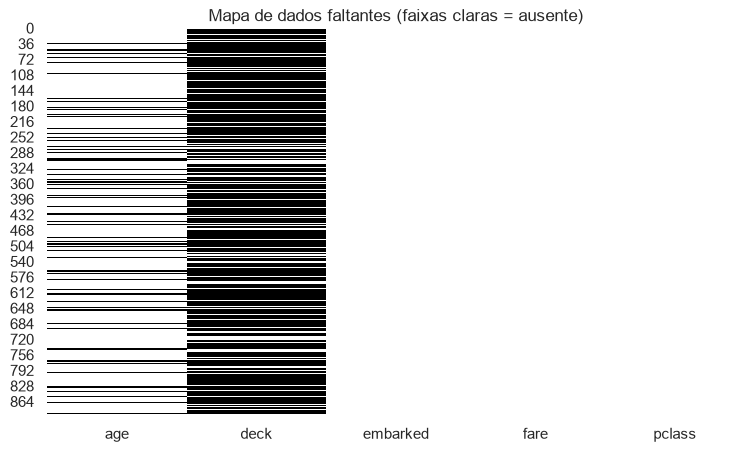

In [24]:
# Mapa de ausência: cada faixa clara é um valor faltante
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(dados[['age', 'deck', 'embarked', 'fare', 'pclass']].isna(),
            cbar=False, cmap='Greys', ax=ax)
ax.set_title('Mapa de dados faltantes (faixas claras = ausente)')
plt.show()

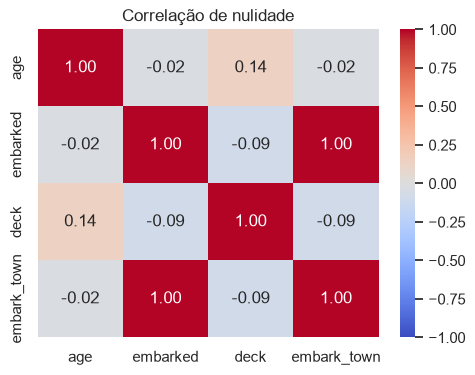

In [25]:
# Correlação de NULIDADE: a ausência de uma coluna acompanha a ausência de outra?
colunas_com_falta = dados.columns[dados.isna().any()]
correlacao_nulidade = dados[colunas_com_falta].isna().corr()

fig, ax = plt.subplots(figsize=(5.5, 4))
sns.heatmap(correlacao_nulidade, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, ax=ax)
ax.set_title('Correlação de nulidade')
plt.show()

**Como ler.** Cada célula responde: *quando esta coluna falta, aquela outra também falta?* Valores altos indicam colunas que **faltam juntas** — sinal de que vêm da mesma fonte, do mesmo formulário ou do mesmo sistema.

E há um número gritante aqui:

| | age | embarked | deck | embark_town |
|---|---|---|---|---|
| **age** | 1,00 | −0,02 | 0,14 | −0,02 |
| **embarked** | −0,02 | 1,00 | −0,09 | **1,00** |
| **deck** | 0,14 | −0,09 | 1,00 | −0,09 |
| **embark_town** | −0,02 | **1,00** | −0,09 | 1,00 |

**`embarked` × `embark_town` = 1,00 exato.** Correlação perfeita de ausência significa que, sempre que uma falta, a outra falta **sem uma única exceção**. É a assinatura de duas colunas geradas da mesma fonte — e confirma, por outro caminho, o que a seção de categóricas já tinha sugerido: `embark_town` é apenas `embarked` escrito por extenso.

> **Repare no método:** chegamos à mesma conclusão duas vezes, por evidências independentes (cardinalidade idêntica e nulidade idêntica). Quando dois indícios não relacionados apontam para a mesma coisa, a hipótese fica bem mais forte. É assim que EDA constrói confiança.

**`age` × `deck` = 0,14** — fraca, mas positiva. Há uma leve tendência de faltarem juntas, o que faz sentido: ambas dependem de um registro mais cuidadoso do passageiro.

As demais estão perto de zero: as ausências são independentes entre si.

> A biblioteca [`missingno`](https://github.com/ResidentMario/missingno) faz esses gráficos prontos (`msno.matrix`, `msno.heatmap`, `msno.dendrogram`); aqui reproduzimos na mão para não depender de instalação.

<div id="mcar-mar-mnar"></div>

### MCAR, MAR e MNAR

Existem três mecanismos de ausência, e a distinção importa porque determina **se ignorar ou imputar ingenuamente introduz viés**:

| Mecanismo | Definição | Exemplo |
|---|---|---|
| **MCAR** | A ausência não depende de nada — nem do valor ausente, nem das outras variáveis | Sensor que falha por queda de energia aleatória |
| **MAR** | A ausência depende de variáveis **observadas**, mas não do valor ausente em si | Certo grupo responde menos à pergunta de renda — a ausência depende do grupo, que você tem |
| **MNAR** | A ausência depende do **próprio valor ausente** | Quem tem renda muito alta tende a não informar renda |

> **Ponto conceitual central:** MNAR **não pode ser detectado a partir dos dados observados**, por definição — a informação que distinguiria MAR de MNAR é justamente a que está faltando. <br>
Diferenciar os dois é sempre um **argumento sobre o processo que gerou os dados**, nunca um teste estatístico.

### Como tratar cada mecanismo

**O princípio geral:** o mecanismo determina o que é seguro fazer. Aplicar o mesmo tratamento aos três é o erro mais comum — e o mais caro.

---

#### MCAR — o caso benigno

A ausência não depende de nada. Consequência prática: **descartar as linhas não enviesa a amostra**, apenas desperdiça dados. Se a proporção de faltantes for pequena, remover é legítimo e não distorce nada.

Imputar pela média/mediana/moda também funciona sem introduzir viés sistemático. O único custo é a variância artificialmente comprimida (você empilha muitos pontos no mesmo valor).

> **É o único caso em que `dropna()` é defensável.** E é raro na prática — a maioria das ausências que parecem aleatórias não são.

---

#### MAR — o caso tratável

A ausência depende de variáveis **observadas**. Como você tem essas variáveis, a imputação pode usá-las — e precisa usá-las.

Em ordem crescente de qualidade:

**1. Média/mediana global** — evite. Ignora justamente a informação que torna o problema tratável, e comprime a variância da coluna.

**2. Média/mediana por grupo** — no Titanic, mediana de idade por `pclass` × `sex`. Simples, transparente, respeita o mecanismo. Para muitos projetos reais, é suficiente.

**3. Imputação por modelo** — `IterativeImputer` (a implementação do MICE no scikit-learn), `KNNImputer`, MissForest. Cada coluna com faltantes é prevista a partir das demais, iterativamente. Captura relações não-lineares e interações que a média por grupo não pega.

**4. Imputação múltipla** — a resposta tecnicamente correta. Gera **várias** bases imputadas (5 a 10), com variação aleatória entre elas, analisa todas e combina os resultados.

> **Por que múltipla?** Toda imputação única — inclusive as sofisticadas — trata o valor imputado como se fosse observado. Isso finge uma certeza que você não tem, e subestima a incerteza das estimativas. Com várias bases que discordam entre si, essa incerteza é preservada.

**5. Não imputar** — a opção mais subestimada. LightGBM, XGBoost e CatBoost tratam `NaN` nativamente, aprendendo em cada *split* para qual lado mandar os ausentes. Isso permite ao modelo usar a **própria ausência como sinal**, coisa que qualquer imputação apaga.

**Qual escolher depende do objetivo:**

| Contexto | Recomendação |
|---|---|
| **Inferência** (intervalos de confiança, p-valores, conclusão a defender) | Imputação múltipla — é o padrão da literatura |
| **ML preditivo** com árvores | Não imputar, ou imputação por grupo/modelo |
| **ML preditivo** com modelos lineares/redes | Imputação por modelo, dentro de um `Pipeline` |

---

#### MNAR — o caso difícil

A ausência depende do **próprio valor ausente**. Consequência: **qualquer imputação baseada apenas nos dados observados introduz viés sistemático**, porque a informação que você precisaria está justamente no que falta.

Exemplo: se quem tem renda alta tende a não informar renda, imputar pela média puxa a estimativa para baixo — e o erro acontece sempre na mesma direção, então não se cancela quando você agrega.

O que dá para fazer:

- **Modelar a ausência explicitamente** — criar a indicadora e deixar o modelo usá-la. Não corrige o viés na variável, mas preserva a informação de que ela falta;
- **Análise de sensibilidade** — imputar sob hipóteses diferentes (ex.: "os ausentes valem 20% acima da média") e verificar se a conclusão muda. Se muda, você sabe que o resultado é frágil;
- **Buscar a informação fora dos dados** — conversar com quem gerou a base, cruzar com outra fonte. Frequentemente é a única solução real.

> **O mais importante:** MNAR **não pode ser detectado a partir dos dados observados**, por definição — a informação que distinguiria MAR de MNAR é justamente a que está faltando. Diferenciar os dois é sempre um **argumento sobre o processo que gerou os dados**, nunca um teste estatístico.

---

#### Duas regras que valem para os três casos

- **Crie a indicadora.** `age_ausente` junto com o valor imputado. Custa uma coluna e preserva a informação de que aquele dado foi inventado;
- **Impute dentro do `Pipeline`.** O imputador aprende estatísticas dos dados; ajustá-lo na base inteira antes do *split* vaza informação do teste para o treino. Mesmo argumento do `PowerTransformer`. (Aula 2.)

<div id="diagnostico-faltantes"></div>

### Diagnosticando o mecanismo na prática

Duas técnicas resolvem a maior parte dos casos. A primeira: **a ausência depende de outras variáveis observadas?**

In [26]:
# Proporção de idade faltante por classe do bilhete
tabela = (dados.assign(age_ausente=dados['age'].isna())
                .groupby('pclass', observed=True)['age_ausente']
                .agg(taxa_ausencia='mean', n='size')
                .round(3))
tabela

,taxa_ausencia,n
pclass,,
1,0.139,216
2,0.060,184
3,0.277,491


...<p>
A idade falta **muito mais na 3ª classe** do que na 1ª. Ou seja, a ausência está relacionada a uma variável **observada** (`pclass`): isso é evidência de **MAR**, não de MCAR.

> **Decisão de modelagem:** imputar a média *global* de idade seria ruim, porque a média da 1ª classe é diferente da média da 3ª. A imputação precisa ser **condicionada** ao grupo.

<div id="indicadora"></div>

### A ausência como informação

A segunda técnica: **a ausência prevê o alvo?**

In [27]:
dados['age_ausente'] = dados['age'].isna().astype(int)

comparacao = (dados.groupby('age_ausente')
                    .agg(taxa_sobrevivencia=('survived', 'mean'),
                         n=('survived', 'size'),
                         tarifa_media=('fare', 'mean'))
                    .round(3))
comparacao

,taxa_sobrevivencia,n,tarifa_media
age_ausente,,,
0,0.406,714,34.695
1,0.294,177,22.159


Quem tem idade faltante sobreviveu menos: 29,4% contra 40,6%. A diferença é estatisticamente sólida (qui-quadrado, p = 0,008).

**Mas cuidado com a interpretação.** Existe uma explicação alternativa: a idade falta muito mais na 3ª classe (28%) do que na 1ª (14%), e a 3ª classe sobreviveu muito menos. Talvez `age_ausente` não carregue informação nenhuma além do que `pclass` já dá.

Controlando pela classe, o efeito **quase desaparece** na 3ª classe (25,0% contra 23,9%) — justamente onde estão 136 dos 177 casos. O que sobra está na 1ª e 2ª classe, com n de 30 e 11 — pequeno demais para sustentar conclusão.

> **Decisão de modelagem:** criar `age_ausente` mesmo assim, porque criar uma coluna é barato e o modelo decide se ela serve. Mas registrar a ressalva: o efeito bruto é largamente explicado por `pclass`, e a coluna pode não agregar nada.

> **O método que fica:** toda relação bivariada precisa ser replicada dentro dos principais segmentos antes de virar conclusão. Foi isso que acabamos de fazer — e é exatamente o assunto do paradoxo de Simpson, mais adiante nesta aula.

[Voltar ao Índice](#indice)

___
<div id="bivariada"></div>

## 5. Análise bivariada e multivariada

<div id="correlacao"></div>

### Correlação: Pearson, Spearman e Kendall

| Medida | O que captura | Robustez | Quando usar |
|---|---|---|---|
| **Pearson** | Relação **linear** | Baixa — muito sensível a outliers | Quando você espera linearidade e os dados são bem comportados |
| **Spearman** | Relação **monotônica** (via *ranks*) | Alta | Padrão de fato em EDA de ML |
| **Kendall** ($\tau$) | Concordância de pares | Alta | Amostras pequenas ou com muitos empates; mais custosa |

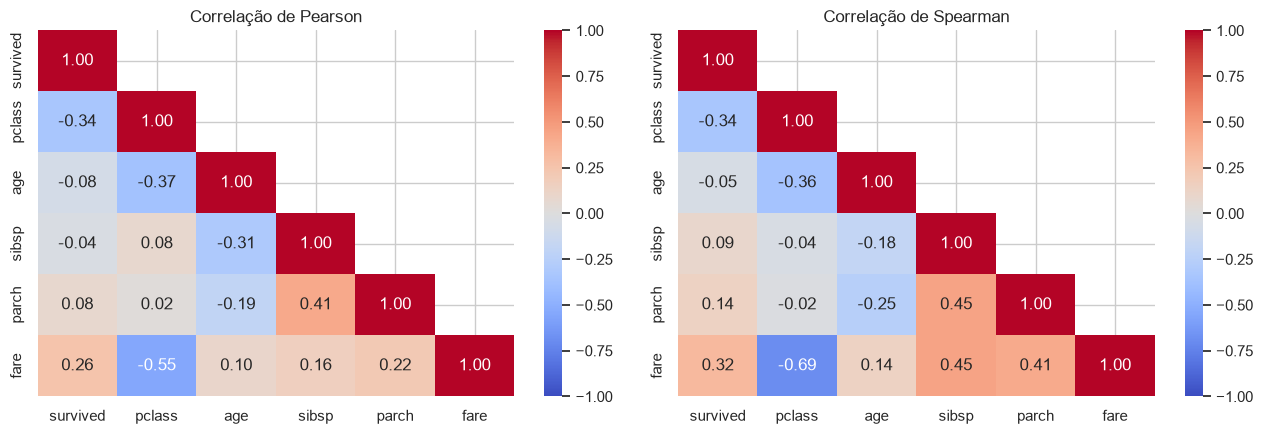

In [28]:
colunas_numericas = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, metodo in zip(axes, ['pearson', 'spearman']):
    matriz = dados[colunas_numericas].corr(method=metodo)
    mascara = np.triu(np.ones_like(matriz, dtype=bool), k=1)
    sns.heatmap(matriz, mask=mascara, annot=True, fmt='.2f', cmap='coolwarm',
                vmin=-1, vmax=1, center=0, ax=ax)
    ax.set_title(f'Correlação de {metodo.capitalize()}')

plt.tight_layout()
plt.show()

In [29]:
# Onde os dois métodos mais discordam?
pearson = dados[colunas_numericas].corr(method='pearson')
spearman = dados[colunas_numericas].corr(method='spearman')

diferenca = (spearman - pearson).abs()

# mantém só o triângulo inferior, para não repetir cada par duas vezes
mascara = np.triu(np.ones(diferenca.shape, dtype=bool), k=0)
diferenca = diferenca.mask(mascara)

par = diferenca.stack().idxmax()
print(f'Maior discordância: {par[0]} x {par[1]}')
print(f'  Pearson  = {pearson.loc[par]:.3f}')
print(f'  Spearman = {spearman.loc[par]:.3f}')
print()

# Um segundo par, mais fácil de interpretar:
print('Correlação entre fare e pclass pelos três métodos:')
for metodo in ['pearson', 'spearman', 'kendall']:
    valor = dados['fare'].corr(dados['pclass'], method=metodo)
    print(f'  {metodo:>8}: {valor:>6.3f}')

Maior discordância: fare x sibsp
  Pearson  = 0.160
  Spearman = 0.447

Correlação entre fare e pclass pelos três métodos:
   pearson: -0.549
  spearman: -0.688
   kendall: -0.574


...<p>
**Reflita/discuta:** em ambos os pares o Spearman é bem mais forte que o Pearson. Por quê?

- Em `fare × sibsp`: `sibsp` é uma **contagem** concentrada em 0 e 1, com poucos valores altos, e `fare` tem cauda longa. Quem viaja acompanhado tende a pagar mais (bilhete de família), mas essa relação está longe de ser uma reta;
- Em `fare × pclass`: a relação é **monotônica mas não linear** — a diferença de tarifa entre 1ª e 2ª classe é muito maior que entre 2ª e 3ª.

Nos dois casos Pearson procura uma reta e encontra pouco; Spearman só precisa que a **ordem** seja consistente.

> **Decisão prática:** em EDA de ML, use **Spearman como padrão** e Pearson como complemento. A maioria das relações em dados reais é monotônica sem ser linear.

> **Alerta conceitual:** correlação de Pearson zero **não** significa independência. Uma parábola perfeita ($y = x^2$) centrada em zero tem Pearson $\approx 0$ e a relação é determinística.

Até aqui olhamos uma variável de cada vez. Agora a pergunta muda: **saber o valor de uma variável diz algo sobre a outra?**

As três medidas a seguir respondem isso numa escala de −1 a +1, onde o sinal indica a direção (sobem juntas ou uma sobe e a outra desce) e o valor absoluto indica a força. O que as diferencia é **o que cada uma aceita como "relação"**: Pearson exige uma reta, enquanto Spearman e Kendall só exigem consistência de ordem — se "mais de A" significa sempre "mais de B", basta, não importa o formato da curva.

Essa diferença tem consequência prática direta, e você vai ver isso nos números logo abaixo.

<div id="categoricas"></div>

### E quando a variável é categórica?

O `.corr()` só funciona entre numéricas — mas a maior parte dos dados de empresa é **dominada por categóricas**. As medidas que faltam no arsenal padrão:

- **Cramér's V** — categórica × categórica. Derivada do qui-quadrado, varia de 0 a 1;
- **Razão de correlação ($\eta$)** — categórica × numérica. É a fração da variância da numérica explicada pela categoria (o $R^2$ de uma ANOVA de um fator); e
- **Informação mútua (MI)** — funciona para qualquer combinação de tipos e captura **qualquer** dependência, inclusive não-monotônica.

In [30]:
def cramers_v(x, y):
    """Associação entre duas variáveis categóricas (0 a 1)."""
    tabela = pd.crosstab(x, y)
    qui2 = stats.chi2_contingency(tabela)[0]
    n = tabela.values.sum()
    linhas, colunas = tabela.shape
    return np.sqrt((qui2 / n) / (min(linhas, colunas) - 1))


def razao_correlacao(categoria, numerica):
    """Eta: fração da variância da numérica explicada pela categoria (0 a 1)."""
    df = pd.DataFrame({'c': categoria, 'n': numerica}).dropna()
    media_geral = df['n'].mean()
    entre_grupos = sum(len(g) * (g.mean() - media_geral) ** 2
                       for _, g in df.groupby('c', observed=True)['n'])
    total = ((df['n'] - media_geral) ** 2).sum()
    return np.sqrt(entre_grupos / total)


print("Cramér's V (categórica x categórica)")
print(f"  sex      x survived : {cramers_v(dados['sex'], dados['survived']):.3f}")
print(f"  pclass   x survived : {cramers_v(dados['pclass'], dados['survived']):.3f}")
print(f"  embarked x pclass   : {cramers_v(dados['embarked'].fillna('?'), dados['pclass']):.3f}")
print()
print('Razão de correlação eta (categórica x numérica)')
print(f"  pclass -> fare : {razao_correlacao(dados['pclass'], dados['fare']):.3f}")
print(f"  sex    -> age  : {razao_correlacao(dados['sex'], dados['age']):.3f}")

Cramér's V (categórica x categórica)
  sex      x survived : 0.541
  pclass   x survived : 0.340
  embarked x pclass   : 0.270

Razão de correlação eta (categórica x numérica)
  pclass -> fare : 0.594
  sex    -> age  : 0.093


...<p>
**O achado mais importante da aula até aqui:** `sex` tem a associação **mais forte** com `survived` de todas as variáveis — e ela era completamente invisível na matriz de correlação, porque `sex` é texto. <br>
Uma EDA que só roda `.corr()` teria perdido a variável mais preditiva da base.

In [31]:
# Informação mútua: captura qualquer dependência, inclusive não-monotônica
X_mi = dados[['pclass', 'age', 'fare', 'sibsp', 'parch']].copy()
X_mi['age'] = X_mi['age'].fillna(X_mi['age'].median())
X_mi['sex_cod'] = (dados['sex'] == 'female').astype(int)

mi = mutual_info_classif(X_mi, dados['survived'], random_state=0)

pd.Series(mi, index=X_mi.columns).sort_values(ascending=False).round(4).to_frame('informação mútua')

,informação mútua
sex_cod,0.1673
fare,0.1232
pclass,0.0360
sibsp,0.0314
parch,0.0302
age,0.0250


<div id="causalidade"></div>

### Correlação **não** implica causalidade

Duas variáveis podem estar correlacionadas por coincidência, por uma terceira variável que influencia ambas (*confounder*), ou por uma relação temporal que não é causal. <p>
Exemplo clássico: vendas de sorvete e afogamentos são correlacionados — mas a causa comum é o **verão**. <br>
Na base do Titanic: `fare` está correlacionada com `survived`, mas será que *pagar mais* **causa** sobrevivência — ou a tarifa é apenas um reflexo da **classe** (proximidade dos botes, prioridade de evacuação)?

<div id="simpson"></div>

### O paradoxo de Simpson

A frase acima é abstrata. O paradoxo de Simpson a torna visceral: **uma tendência presente em todos os subgrupos pode desaparecer ou até se inverter quando os grupos são agregados.**

O caso canônico são as admissões da pós-graduação de Berkeley em 1973. Os números abaixo são os dos seis maiores departamentos, como reproduzidos no conjunto de dados clássico derivado do estudo de Bickel, Hammel e O'Connell (*Science*, 1975).

In [32]:
berkeley = pd.DataFrame({
    'departamento': ['A', 'A', 'B', 'B', 'C', 'C', 'D', 'D', 'E', 'E', 'F', 'F'],
    'genero':       ['M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F'],
    'admitidos':    [512,  89, 353,  17, 120, 202, 138, 131,  53,  94,  22,  24],
    'rejeitados':   [313,  19, 207,   8, 205, 391, 279, 244, 138, 299, 351, 317],
})
berkeley['candidatos'] = berkeley['admitidos'] + berkeley['rejeitados']
berkeley['taxa'] = (berkeley['admitidos'] / berkeley['candidatos'] * 100).round(1)

# VISÃO 1: o agregado
agregado = berkeley.groupby('genero')[['admitidos', 'candidatos']].sum()
agregado['taxa_admissao (%)'] = (agregado['admitidos'] / agregado['candidatos'] * 100).round(1)
agregado

,admitidos,candidatos,taxa_admissao (%)
genero,,,
F,557,1835,30.4
M,1198,2691,44.5


...<p>
**Pare aqui e conclua.** A diferença é grande e a amostra é enorme — não é acaso. <br>
Qual é a sua conclusão sobre viés de gênero na admissão?

Agora vamos abrir por departamento:

In [33]:
# VISÃO 2: o mesmo dado, aberto por departamento
por_departamento = berkeley.pivot(index='departamento', columns='genero', values='taxa')
por_departamento.columns = ['Feminino (%)', 'Masculino (%)']
por_departamento['favorece'] = np.where(por_departamento['Feminino (%)'] >= por_departamento['Masculino (%)'],
                                        'mulheres', 'homens')
por_departamento

,Feminino (%),Masculino (%),favorece
departamento,,,
A,82.4,62.1,mulheres
B,68.0,63.0,mulheres
C,34.1,36.9,homens
D,34.9,33.1,mulheres
E,23.9,27.7,homens
F,7.0,5.9,mulheres


In [34]:
# Por que o agregado se inverte? Olhe PARA ONDE cada grupo se candidatou.
contexto = berkeley.pivot(index='departamento', columns='genero', values='candidatos')
contexto.columns = ['candidatas', 'candidatos_M']
contexto['taxa_geral_do_depto (%)'] = (berkeley.groupby('departamento')['admitidos'].sum() /
                                        berkeley.groupby('departamento')['candidatos'].sum() * 100).round(1)
contexto.sort_values('taxa_geral_do_depto (%)', ascending=False)

,candidatas,candidatos_M,taxa_geral_do_depto (%)
departamento,,,
A,108,825,64.4
B,25,560,63.2
C,593,325,35.1
D,375,417,34.0
E,393,191,25.2
F,341,373,6.4


...<p>
**A explicação:** as candidatas se concentraram nos departamentos **mais competitivos** (C, E, F — taxas baixas para todo mundo), e os candidatos nos **menos concorridos** (A e B). O departamento é uma variável confundidora forte o bastante para **inverter o sinal do agregado**.

**Por que isso pertence a uma aula de EDA:** toda correlação que calculamos sobre a base inteira é uma correlação **agregada**. Se existe um confundidor distribuído de forma desigual entre os grupos, o número que você está olhando pode ter o **sinal errado**.

> **Defesa prática (adote como regra):** antes de acreditar numa relação bivariada, **replique o cálculo dentro dos principais segmentos** — região, produto, canal, safra de entrada, período.

<div id="pairplot"></div>

### *Pairplots*

Mostra numa grade a relação entre cada par de variáveis. Ótimo até ~8 variáveis; acima disso vira ilegível. <br>
Em bases grandes, **amostre as linhas** antes de plotar.

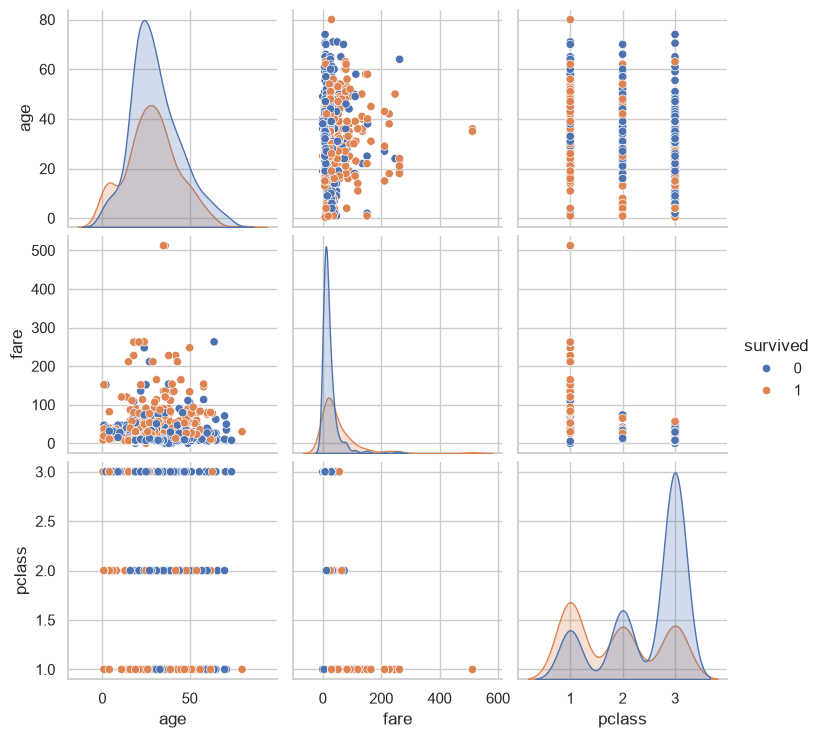

In [35]:
sns.pairplot(dados[['age', 'fare', 'pclass', 'survived']].dropna(), hue='survived')
plt.show()

### Lendo a grade

**A diagonal** mostra a distribuição de cada variável, separada por sobrevivência (azul = morreu, laranja = sobreviveu). É onde está a informação mais direta:

- **`age`** — as duas curvas se sobrepõem quase inteiramente. Idade sozinha separa mal. A exceção é a ponta esquerda, onde há um excesso de laranja: crianças até 12 anos sobreviveram em 58%, contra 38% dos adultos de 18 a 35;
- **`fare`** — a curva laranja está deslocada para a direita. A mediana de tarifa de quem sobreviveu é 26,0; de quem morreu, 10,5. Duas vezes e meia;
- **`pclass`** — o contraste mais forte da grade. A 3ª classe é dominada por azul (24% de sobrevivência), a 1ª por laranja (63%).

**Fora da diagonal** estão os cruzamentos. O painel `age × fare` mostra que os sobreviventes se concentram na faixa de tarifa alta, em qualquer idade — sugerindo que `fare` carrega mais sinal que `age`, o que a análise por decis já tinha indicado.

> **Um defeito visual que vale notar:** `pclass` e `survived` são variáveis **discretas**, mas o pairplot as trata como contínuas. O resultado são aquelas faixas horizontais empilhadas, que não dizem nada sobre densidade — dezenas de pontos sobrepostos parecem um ponto só.
>
> Pairplot é ferramenta para variáveis **contínuas**. Para discretas ou categóricas, use `boxplot`, `violinplot` ou tabelas de taxa por categoria — que é o que fizemos na seção do alvo.

**O que fazer com isso.** O pairplot não é uma ferramenta de conclusão; é de **triagem**. Em poucos segundos ele indica quais pares merecem investigação detalhada. Aqui ele apontou `fare` e `pclass` como candidatas fortes e `age` como fraca — hipóteses que você depois confirma com números, não com o gráfico.

### Comparando dois grupos: o teste t

Correlação mede associação entre duas variáveis numéricas. Mas uma pergunta muito comum em EDA tem outra forma: **a média desta variável difere entre dois grupos?**

Por exemplo: quem sobreviveu pagou tarifa mais alta? Quem sobreviveu era mais jovem?

O **teste t** compara as médias de dois grupos. A hipótese nula é *"as duas médias são iguais na população"*, e um p-valor pequeno é evidência contra ela.

> **Detalhe que importa:** existem duas versões. O teste t **de Student** assume que os dois grupos têm a mesma variância; o de **Welch** não assume. Como variâncias iguais são raras em dados reais, **Welch é o padrão recomendado** — no `scipy`, é `equal_var=False`. O default da função é `True`, então é preciso mudar explicitamente.

In [36]:
def compara_grupos(coluna, alvo='survived'):
    """Compara a distribuição de uma variável entre os dois grupos do alvo."""
    grupo_a = dados.loc[dados[alvo] == 0, coluna].dropna()
    grupo_b = dados.loc[dados[alvo] == 1, coluna].dropna()

    # Teste t de Welch (não assume variâncias iguais)
    t, p_t = stats.ttest_ind(grupo_a, grupo_b, equal_var=False)

    # Mann-Whitney: alternativa por ranks, robusta a assimetria
    _, p_mw = stats.mannwhitneyu(grupo_a, grupo_b)

    # Cohen's d: TAMANHO do efeito (não depende do n)
    dp_combinado = np.sqrt(((len(grupo_a) - 1) * grupo_a.var() +
                            (len(grupo_b) - 1) * grupo_b.var()) /
                           (len(grupo_a) + len(grupo_b) - 2))
    d_cohen = (grupo_b.mean() - grupo_a.mean()) / dp_combinado

    print(f'--- {coluna} ---')
    print(f'  grupo 0: média {grupo_a.mean():>6.2f} | mediana {grupo_a.median():>6.2f} | n {len(grupo_a)}')
    print(f'  grupo 1: média {grupo_b.mean():>6.2f} | mediana {grupo_b.median():>6.2f} | n {len(grupo_b)}')
    print(f'  teste t (Welch) : p = {p_t:.2e}')
    print(f'  Mann-Whitney    : p = {p_mw:.2e}')
    print(f"  Cohen's d       : {d_cohen:+.3f}")
    print()


compara_grupos('fare')
compara_grupos('age')

--- fare ---
  grupo 0: média  22.12 | mediana  10.50 | n 549
  grupo 1: média  48.40 | mediana  26.00 | n 342
  teste t (Welch) : p = 2.70e-11
  Mann-Whitney    : p = 4.55e-22
  Cohen's d       : +0.547

--- age ---
  grupo 0: média  30.63 | mediana  28.00 | n 424
  grupo 1: média  28.34 | mediana  28.00 | n 290
  teste t (Welch) : p = 4.12e-02
  Mann-Whitney    : p = 1.60e-01
  Cohen's d       : -0.157



### Lendo os resultados

**`fare`** — diferença enorme: média 22,12 contra 48,40. O p-valor é 2,7e−11 e o **Cohen's d é 0,55**, considerado efeito médio. As duas medidas concordam: há diferença real e relevante.

**`age`** — média 30,63 contra 28,34. O teste t dá p = 0,041, tecnicamente "significativo" a 5%. Mas o **Cohen's d é −0,16**, efeito pequeno. E o Mann-Whitney dá p = 0,16, que **não** rejeita.

Três resultados discordantes na mesma variável. Por quê?

- O **teste t** compara médias, e a média de `age` é levemente puxada pelos extremos;
- O **Mann-Whitney** compara distribuições por *ranks*. As medianas são idênticas (28,00 nos dois grupos), então ele não vê diferença;
- O **Cohen's d** diz o que realmente importa: a diferença de 2,3 anos representa apenas 0,16 desvio-padrão. É minúscula.

> **A leitura correta:** `fare` separa os grupos de forma relevante; `age` praticamente não separa. O p-valor de 0,041 em `age` é o mesmo fenômeno de sempre — com 714 observações, uma diferença irrelevante cruza o limiar de significância.

### Cohen's d: o tamanho do efeito

Assim como skewness e curtose, o **d de Cohen** mede magnitude e não depende do `n`. Ele expressa a diferença entre as médias em unidades de desvio-padrão:

| \|d\| | Interpretação convencional |
|---|---|
| ~0,2 | pequeno |
| ~0,5 | médio |
| ~0,8 | grande |

São convenções, não regras — o que é "grande" depende do domínio. Mas servem para calibrar o olhar, e sobretudo para **não confundir significância com relevância**.

In [37]:
# O teste t sofre do MESMO problema do n que vimos no Shapiro-Wilk.
# Mesma base, mesma diferença real, variando só quantas linhas olhamos:
print(f"{'n':>5} | {'Cohen d':>10} | {'p-valor':>9} | conclusão")
print('-' * 48)
for n in [20, 50, 200, 891]:
    sub = dados.sample(n, random_state=1)
    a = sub.loc[sub['survived'] == 0, 'fare'].dropna()
    b = sub.loc[sub['survived'] == 1, 'fare'].dropna()
    p = stats.ttest_ind(a, b, equal_var=False).pvalue
    dp = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
    d = (b.mean() - a.mean()) / dp
    print(f'{n:>5} | {d:>10.2f} | {p:>9.4f} | '
          f'{"significativo" if p < 0.05 else "não significativo"}')

    n |    Cohen d |   p-valor | conclusão
------------------------------------------------
   20 |      -0.19 |    0.6737 | não significativo
   50 |       0.51 |    0.0977 | não significativo
  200 |       0.49 |    0.0034 | significativo
  891 |       0.55 |    0.0000 | significativo


A partir de n = 50, o **Cohen's d estabiliza em torno de 0,5** — o tamanho do efeito é o mesmo, porque é uma propriedade dos dados. Já o p-valor despenca de 0,67 para praticamente zero conforme o `n` cresce.

> **A mesma lição, terceira vez:** o p-valor mede **detectabilidade**; o tamanho do efeito mede **magnitude**. Reporte sempre os dois — e quando eles discordarem, é o tamanho do efeito que responde à pergunta que o negócio realmente fez.

### Quando usar cada ferramenta

| Situação | Ferramenta |
|---|---|
| Comparar médias de dois grupos | Teste t de **Welch** + Cohen's d |
| Dados muito assimétricos ou com outliers | **Mann-Whitney** (compara por *ranks*) |
| Mais de dois grupos | ANOVA, ou razão de correlação $\eta$ (próxima subseção) |
| Duas variáveis numéricas | Correlação (Pearson/Spearman) |

[Voltar ao Índice](#indice)

___
<div id="outliers"></div>

## 6. Detecção de outliers

<div id="tipos-outlier"></div>

### Outlier de quê? Três coisas diferentes

Confundir os três é a causa de decisões ruins:

1. **Erro de dados** — sentinela, erro de digitação, unidade errada. **Deve** ser corrigido ou removido;
2. **Evento raro legítimo** — a tarifa de £512 existiu mesmo. Remover é destruir informação. Em detecção de fraude, é literalmente remover a classe de interesse; e
3. **Ponto influente** — não é extremo em nenhuma variável isolada, mas distorce desproporcionalmente o ajuste.

> **Nenhum algoritmo distingue (1) de (2).** Essa distinção é sempre de **domínio**. O papel da EDA é *encontrar* os candidatos e levar a pergunta certa a quem conhece o negócio.

<div id="zscore"></div>

### Z-score e Z-score robusto

O **Z-score** mede quantos desvios-padrão o valor está da média:

$$Z = \frac{x - \bar{x}}{s}$$

**O defeito é autorreferente:** a média e o desvio-padrão são calculados **com os outliers dentro**. Um valor extremo infla o desvio-padrão o suficiente para se esconder dentro do próprio corte — fenômeno chamado de **mascaramento**.

O **Z-score robusto** troca média por mediana e desvio-padrão pelo **MAD** (desvio absoluto mediano), duas estatísticas que os outliers não conseguem contaminar:

$$Z_{rob} = \frac{0{,}6745\,(x - \tilde{x})}{MAD}$$

A constante $0{,}6745$ escala o MAD para ficar comparável ao desvio-padrão de uma normal, mantendo a interpretação do limiar.

In [38]:
fare = dados['fare']

# Z-score clássico
z = (fare - fare.mean()) / fare.std()

# Z-score robusto (mediana + MAD)
z_robusto = 0.6745 * (fare - np.median(fare)) / median_abs_deviation(fare)

print(f'Média = {fare.mean():.2f}   | Desvio-padrão = {fare.std():.2f}')
print(f'Mediana = {np.median(fare):.2f}  | MAD = {median_abs_deviation(fare):.2f}')
print()
print(f'Outliers por |Z| > 3.0         : {(z.abs() > 3).sum():>3}')
print(f'Outliers por |Z robusto| > 3.5 : {(z_robusto.abs() > 3.5).sum():>3}')

Média = 32.20   | Desvio-padrão = 49.69
Mediana = 14.45  | MAD = 6.90

Outliers por |Z| > 3.0         :  20
Outliers por |Z robusto| > 3.5 : 160


...<p>
Compare as duas primeiras linhas. A mediana (14,45) é bem menor que a média (32,20), o que já sabíamos. Mas o ponto decisivo é a **dispersão**: o desvio-padrão é ~50, enquanto o MAD é ~7. <br>
Convertendo o MAD para a mesma escala de um desvio-padrão ($MAD / 0{,}6745 \approx 10$), o desvio-padrão clássico é **cerca de cinco vezes maior** — porque foi inflado pelas próprias tarifas extremas que deveria detectar. É o **mascaramento** em ação.

Resultado: o critério clássico enxerga apenas 20 pontos; o robusto enxerga 160.

> **Não existe resposta "certa" aqui.** O robusto está tecnicamente correto ao dizer que aqueles 160 pontos estão longe do centro. Mas isso é consequência da **assimetria natural** de `fare`, não de anomalia. É por isso que a próxima seção importa.

<div id="iqr"></div>

### IQR (Intervalo Interquartil)

$IQR = Q3 - Q1$. São outliers os valores abaixo de $Q1 - 1{,}5 \times IQR$ ou acima de $Q3 + 1{,}5 \times IQR$. <br>
Não assume normalidade e é o critério usado pelo **boxplot**.

De onde vem o $1{,}5$? Numa distribuição normal, esse fator marca aproximadamente $0{,}7\%$ dos pontos como extremos. Em distribuições assimétricas, o IQR sinaliza muitos pontos da cauda longa sem que sejam anômalos — o que é um argumento para **transformar antes** de aplicar o critério.

In [39]:
q1, q3 = fare.quantile(0.25), fare.quantile(0.75)
iqr = q3 - q1
limite_inferior, limite_superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr

outliers_iqr = dados.loc[(fare < limite_inferior) | (fare > limite_superior)]

print(f'Q1 = {q1:.2f} | Q3 = {q3:.2f} | IQR = {iqr:.2f}')
print(f'Limites: [{limite_inferior:.2f}, {limite_superior:.2f}]')
print(f'Outliers pelo IQR: {len(outliers_iqr)}')
print()

# E se aplicarmos o mesmo critério DEPOIS da transformação log?
fare_t = np.log1p(fare)
q1_t, q3_t = fare_t.quantile(0.25), fare_t.quantile(0.75)
iqr_t = q3_t - q1_t
n_t = ((fare_t < q1_t - 1.5 * iqr_t) | (fare_t > q3_t + 1.5 * iqr_t)).sum()
print(f'Outliers pelo IQR APÓS log1p: {n_t}')

Q1 = 7.91 | Q3 = 31.00 | IQR = 23.09
Limites: [-26.72, 65.63]
Outliers pelo IQR: 116

Outliers pelo IQR APÓS log1p: 31


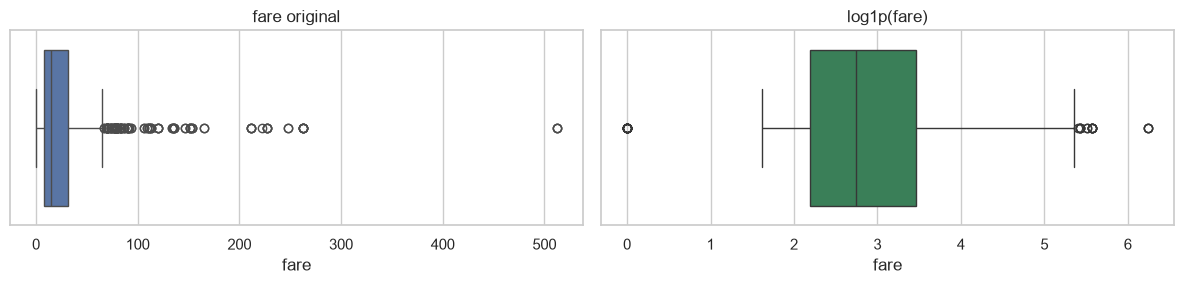

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
sns.boxplot(x=fare, ax=axes[0])
axes[0].set_title('fare original')
sns.boxplot(x=fare_t, ax=axes[1], color='seagreen')
axes[1].set_title('log1p(fare)')
plt.tight_layout()
plt.show()

...<p>
**Reflita/discuta:** os mesmos dados, o mesmo critério — e o número de outliers despenca depois do log. <br>
Isso significa que a transformação "resolveu" os outliers? Ou significa que boa parte do que o IQR chamava de outlier era só **a cauda natural de uma distribuição assimétrica**?

<div id="isolation"></div>

### Isolation Forest: outliers multivariados

Z-score e IQR são aplicados **variável por variável**. O caso que motiva o método multivariado:

> uma pessoa de 15 anos não é outlier de idade; uma tarifa de £150 não é outlier de tarifa; mas **um menino de 15 anos de 3ª classe pagando £150** é claramente anômalo — e nenhum método univariado enxerga isso.

O **Isolation Forest** isola pontos com cortes aleatórios: anômalos ficam sozinhos com poucos cortes, normais exigem muitos. <br>
**Atenção ao hiperparâmetro `contamination`:** ele *define* quantos pontos serão marcados. É uma escolha sua, não uma descoberta do algoritmo.

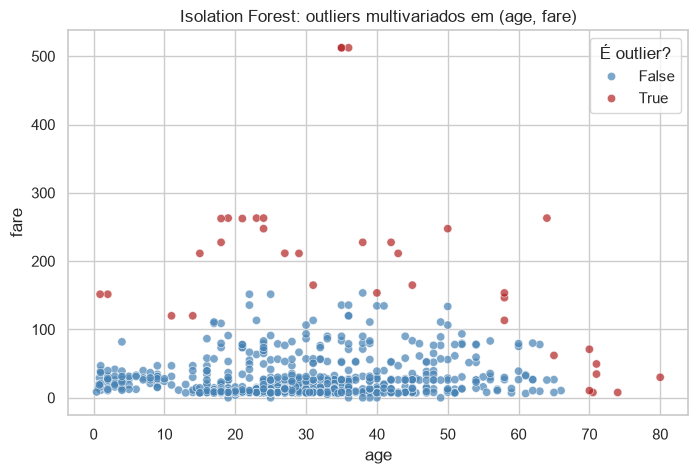

Pontos marcados como outlier: 36 de 714


In [41]:
dados_completos = dados[['age', 'fare']].dropna()

modelo_isolation = IsolationForest(contamination=0.05, random_state=42)
rotulos = modelo_isolation.fit_predict(dados_completos)   # -1 = outlier; 1 = normal

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=dados_completos['age'], y=dados_completos['fare'],
                hue=(rotulos == -1), palette={False: 'steelblue', True: 'firebrick'},
                alpha=0.7, ax=ax)
ax.set_title('Isolation Forest: outliers multivariados em (age, fare)')
ax.legend(title='É outlier?')
plt.show()

print(f'Pontos marcados como outlier: {(rotulos == -1).sum()} de {len(dados_completos)}')

<div id="impacto-modelo"></div>

### O impacto depende do modelo

| Família de modelo | Sensibilidade | Motivo |
|---|---|---|
| Linear / logística (MSE) | **Muito alta** | O erro quadrático penaliza desvios grandes de forma quadrática — poucos pontos dominam o ajuste |
| KNN, SVM, k-means | **Muito alta** | Baseados em distância; a escala distorcida contamina toda a métrica |
| Redes neurais | Alta | Gradientes grandes desestabilizam o treino |
| Árvores e ensembles | **Baixa** | *Splits* usam ordem, não magnitude — o outlier acaba isolado numa folha |

> **Conclusão da seção:** a decisão sobre outliers **não é uma propriedade dos dados** — é uma decisão conjunta de *dados e modelo*. Se o destino é LightGBM, gastar duas horas tratando outliers geralmente não muda nada. Se é uma regressão linear que vai para um relatório regulatório, muda tudo.

[Voltar ao Índice](#indice)

___
<div id="alvo"></div>

## 7. A variável-alvo

Até aqui tratamos todas as colunas de forma simétrica. Mas **o alvo merece uma análise própria**, porque quase toda decisão da Aula 2 (métrica) e da Aula 5 (modelo) já está condicionada pelo que vemos aqui.

In [42]:
contagem = dados['survived'].value_counts().sort_index()
proporcao = dados['survived'].value_counts(normalize=True).sort_index()

print('Distribuição do alvo (survived):')
for classe in contagem.index:
    print(f'  classe {classe}: {contagem[classe]:>4} linhas ({proporcao[classe]:.1%})')
print()
print(f'Classe minoritária em valor ABSOLUTO: {contagem.min()} exemplos')

Distribuição do alvo (survived):
  classe 0:  549 linhas (61.6%)
  classe 1:  342 linhas (38.4%)

Classe minoritária em valor ABSOLUTO: 342 exemplos


...<p>
**As duas perguntas que importam:**

1. Qual é a **proporção** da classe positiva? Aqui ~38% — desbalanceamento leve, nada dramático;
2. Quantos exemplos positivos existem em **valor absoluto**? Esse número, e não o percentual, é o que determina se o problema é aprendível. 0,5% de 10 milhões de linhas são 50 mil positivos (bastante); 0,5% de 2 mil linhas são 10 positivos (inviável).

> **Decisão de modelagem:** com esse desbalanceamento, acurácia ainda é interpretável, mas o *stratified k-fold* já é obrigatório para garantir que todas as *folds* tenham proporção parecida (Aula 2).

In [43]:
# Relação de cada feature com o alvo: taxa por categoria + VOLUME
for coluna in ['sex', 'pclass', 'embarked']:
    tabela = (dados.groupby(coluna, observed=True)
                    .agg(taxa_sobrevivencia=('survived', 'mean'), n=('survived', 'size'))
                    .round(3)
                    .sort_values('taxa_sobrevivencia', ascending=False))
    print(f'--- {coluna} ---')
    print(tabela)
    print()

--- sex ---
        taxa_sobrevivencia    n
sex                            
female               0.742  314
male                 0.189  577

--- pclass ---
        taxa_sobrevivencia    n
pclass                         
1                    0.630  216
2                    0.473  184
3                    0.242  491

--- embarked ---
          taxa_sobrevivencia    n
embarked                         
C                      0.554  168
Q                      0.390   77
S                      0.337  644



...<p>
**Sempre reporte o `n` junto da taxa.** Uma categoria com taxa de 100% e 3 observações não é um achado, é ruído. <br>
É o erro mais comum em apresentações de EDA.

In [44]:
# Para variáveis numéricas: dividir em decis revela a FORMA da relação
analise_decis = (dados.assign(decil=pd.qcut(dados['fare'], 10, duplicates='drop'))
                        .groupby('decil', observed=True)
                        .agg(taxa_sobrevivencia=('survived', 'mean'),
                             n=('survived', 'size'),
                             fare_medio=('fare', 'mean'))
                        .round(3))
analise_decis

,taxa_sobrevivencia,n,fare_medio
decil,,,
"(-0.001, 7.55]",0.141,92,5.929
"(7.55, 7.854]",0.299,87,7.768
"(7.854, 8.05]",0.179,106,7.964
"(8.05, 10.5]",0.231,78,9.521
"(10.5, 14.454]",0.429,84,12.940
"(14.454, 21.679]",0.420,88,17.386
"(21.679, 27.0]",0.517,89,25.488
"(27.0, 39.688]",0.374,91,32.282
"(39.688, 77.958]",0.528,89,59.445


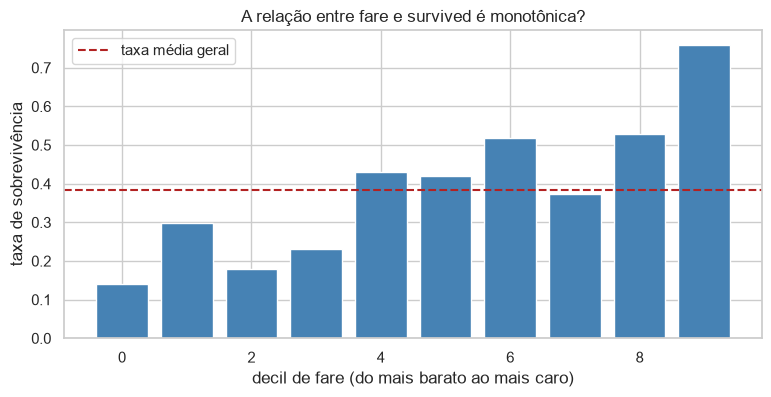

In [45]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(analise_decis)), analise_decis['taxa_sobrevivencia'], color='steelblue')
ax.axhline(dados['survived'].mean(), color='firebrick', linestyle='--', label='taxa média geral')
ax.set_xlabel('decil de fare (do mais barato ao mais caro)')
ax.set_ylabel('taxa de sobrevivência')
ax.set_title('A relação entre fare e survived é monotônica?')
ax.legend()
plt.show()

In [46]:
# Demonstrando: a coluna 'alive' é o alvo escrito em texto
print(pd.crosstab(dados['alive'], dados['survived']))
print()
print('Uma feature que reproduz perfeitamente o alvo daria um modelo de AUC 1.0 --- e 0% de utilidade real.')

survived    0    1
alive             
no        549    0
yes         0  342

Uma feature que reproduz perfeitamente o alvo daria um modelo de AUC 1.0 --- e 0% de utilidade real.


### Lendo o gráfico

Cada barra é um **grupo de tamanho igual** — os 10% que pagaram menos formam o decil 0, os 10% que pagaram mais formam o decil 9. A linha vermelha marca a taxa média geral, 38,4%.

O objetivo aqui não é medir a *força* da relação (a correlação já fez isso), e sim revelar o **formato** dela.

| decil | tarifa média | taxa de sobrevivência |
|---|---|---|
| 0 | 5,93 | 14,1% |
| 1 | 7,77 | 29,9% |
| 2 | 7,96 | 17,9% |
| 3 | 9,52 | 23,1% |
| 4 | 12,94 | 42,9% |
| 5 | 17,39 | 42,0% |
| 6 | 25,49 | 51,7% |
| 7 | 32,28 | 37,4% |
| 8 | 59,45 | 52,8% |
| 9 | 146,81 | **75,9%** |

**A tendência é forte e clara:** do decil 0 ao 9, a taxa vai de 14% para 76% — mais de cinco vezes. Tarifa carrega bastante sinal.

**Mas o caminho não é uma escada limpa.** Do decil 1 para o 2 a taxa *cai* (30% → 18%), do 6 para o 7 também (52% → 37%), e os decis 4-5 formam um platô.

**Por que isso acontece.** Olhe as tarifas médias dos decis 1, 2 e 3: 7,77, 7,96 e 9,52 — praticamente idênticas. São todos passageiros de 3ª classe pagando quase a mesma coisa. Dividir esse aglomerado em três grupos não separa nada de real, e a variação entre eles é sobretudo ruído. Já no topo a escala se abre: o decil 9 tem tarifa média de 146,81 contra 59,45 do decil 8 — efeito da cauda longa de `fare`.

### O que isso alimenta na Aula 3

**Binning.** Se a relação fosse uma reta perfeita, um modelo linear a capturaria sozinho. Como ela tem platôs e degraus, agrupar a tarifa em faixas pode ajudar modelos lineares a representar essa forma irregular.

**Onde cortar.** O gráfico sugere três faixas naturais em vez de dez: decis 0-3 (tarifa baixa, taxa ~20%), decis 4-8 (taxa ~45%) e decil 9 (76%). Bem mais informativo que dividir em dez pedaços iguais.

> **A ressalva:** com ~90 pessoas por decil, a incerteza de cada barra é considerável — uma diferença de 10 pontos percentuais entre decis vizinhos está dentro do que a amostragem produz por acaso.
>
> **Confie na tendência, desconfie das barras individuais.** É o mesmo cuidado com ruído que discutimos nos testes de normalidade, agora em forma de gráfico.

[Voltar ao Índice](#indice)

___
<div id="drift"></div>

## 8. Treino × teste: distribuições e *drift*

Dissemos no começo que modelos falham em produção por algo visível nos dados. Esta seção é o elo faltante: **as distribuições de treino e de produção são as mesmas?**

**Vocabulário:**

- **Covariate shift** — a distribuição das *entradas* muda; a relação entrada→alvo permanece;
- **Concept drift** — a **relação** entre entrada e alvo muda. Bem mais grave: o que o modelo aprendeu deixou de ser verdade; e
- **Prior shift** — a proporção das classes muda.

<div id="adversarial"></div>

### *Adversarial validation*

A técnica é engenhosa e simples:

1. Junte treino e teste e **descarte o alvo original**;
2. Crie um rótulo binário novo: `0` para linhas do treino, `1` para linhas do teste;
3. Treine um classificador para prever esse rótulo e avalie com validação cruzada.

**Leitura do resultado:**

- **AUC ≈ 0,5** — o classificador não distingue a origem das linhas. As distribuições são consistentes. **Sinal verde**;
- **AUC ≈ 1,0** — treino e teste são facilmente separáveis. As distribuições diferem. **Sinal vermelho**.

In [47]:
features = dados[['pclass', 'age', 'sibsp', 'parch', 'fare']].copy()


def auc_adversarial(parte_a, parte_b):
    """Quão fácil é distinguir de qual conjunto veio cada linha?"""
    X = pd.concat([parte_a, parte_b], ignore_index=True)
    y = np.r_[np.zeros(len(parte_a)), np.ones(len(parte_b))]
    return cross_val_score(HistGradientBoostingClassifier(random_state=0),
                           X, y, cv=5, scoring='roc_auc').mean()


# CENÁRIO 1: split aleatório (o que esperamos de um split bem feito)
treino, teste = train_test_split(features, test_size=0.3, random_state=42)
print(f'Split ALEATÓRIO           -> AUC = {auc_adversarial(treino, teste):.3f}')

# CENÁRIO 2: split por uma variável que NEM ESTÁ nas features (porto de embarque)
porto = dados['embarked'].fillna('S')
parte_a = features[porto != 'C']
parte_b = features[porto == 'C']
print(f"Split por embarked == 'C' -> AUC = {auc_adversarial(parte_a, parte_b):.3f}")

Split ALEATÓRIO           -> AUC = 0.485


Split por embarked == 'C' -> AUC = 0.896


...<p>
O primeiro cenário dá ~0,5: perfeito, é o que um split aleatório deve produzir. <br>
O segundo dispara — e repare no detalhe **crucial**: `embarked` **não está** entre as *features*. Mesmo assim o classificador separa os grupos com facilidade, porque quem embarcou em Cherbourg era sistematicamente mais rico.

E agora a parte mais útil da técnica: **descobrir qual variável é a culpada.**

In [48]:
X_adv = pd.concat([parte_a, parte_b], ignore_index=True)
y_adv = np.r_[np.zeros(len(parte_a)), np.ones(len(parte_b))]

X_tr, X_te, y_tr, y_te = train_test_split(X_adv, y_adv, test_size=0.3,
                                          random_state=0, stratify=y_adv)

modelo_adv = HistGradientBoostingClassifier(random_state=0).fit(X_tr, y_tr)
importancia = permutation_importance(modelo_adv, X_te, y_te, n_repeats=10,
                                     random_state=0, scoring='roc_auc')

(pd.Series(importancia.importances_mean, index=X_adv.columns)
   .sort_values(ascending=False)
   .round(4)
   .to_frame('quanto essa feature denuncia a origem da linha'))

,quanto essa feature denuncia a origem da linha
fare,0.3038
pclass,0.0539
age,0.0099
sibsp,0.0084
parch,0.0038


...<p>
`fare` é, disparado, a variável que mais mudou entre os dois grupos. <br>
Em um caso real, esse resultado leva a uma de três ações: **remover** a feature instável, **reconstruí-la** de forma robusta, ou **reponderar** o treino para se parecer com o alvo de produção.

> **Por que isso importa tanto:** são dez linhas de código, o resultado é um único número interpretável, e o conceito liga a Aula 1 diretamente ao **monitoramento em produção** — que é o que diferencia quem já colocou modelo no ar de quem só treinou em notebook. <br>
> Em produção, detectar *drift* é literalmente refazer parte desta EDA continuamente e comparar com a linha de base de hoje.

[Voltar ao Índice](#indice)

___
<div id="ferramentas"></div>

## 9. Ferramentas que automatizam parte da EDA

| Ferramenta | Para quê |
|---|---|
| [`ydata-profiling`](https://docs.profiling.ydata.ai/) | Relatório completo em uma linha: distribuições, correlações, faltantes, alertas |
| [`sweetviz`](https://github.com/fbdesignpro/sweetviz) | Comparar **dois** dataframes lado a lado (ótimo para o treino × teste da seção 8) |
| [`missingno`](https://github.com/ResidentMario/missingno) | Visualização de padrões de ausência |
| [`phik`](https://phik.readthedocs.io/) | Matriz de correlação para tipos mistos |
| [`pandera`](https://pandera.readthedocs.io/) / `Great Expectations` | Transformam regras de qualidade em **testes automatizados** que rodam a cada carga |

**São um ótimo ponto de partida — mas não substituem a análise crítica.** A ferramenta mostra *o quê*; quem formula hipóteses e decide *o que fazer* é você. Nenhuma delas sabe qual é o alvo, qual é a regra de negócio, nem o que é fisicamente possível.

> **Aviso de escala:** o `ydata-profiling` calcula interações par a par; em bases grandes ele fica lento ou estoura memória. Amostre as linhas e restrinja as colunas antes de rodar.

In [49]:
# Remova o # das linhas abaixo para gerar o relatório automático
# (a instalação pode demorar alguns minutos)

# !pip install ydata-profiling      # rode uma vez, se ainda não tiver instalado

# from ydata_profiling import ProfileReport

# relatorio = ProfileReport(dados.sample(500, random_state=0),
#                           title='EDA automática - Titanic')
# relatorio.to_file('relatorio_eda.html')
# print('Relatório salvo em relatorio_eda.html — abra no navegador.')


___
<div id="decisao"></div>

## 10. Do achado à decisão

EDA que termina em gráficos bonitos não serve para nada. **Todo achado precisa virar uma decisão.**

Um insight acionável tem quatro partes:

| Componente | Pergunta |
|---|---|
| **Observação** | O que eu vi nos dados? |
| **Hipótese** | Por que isso acontece? |
| **Decisão** | O que muda na modelagem? |
| **Destino** | Onde essa decisão é executada? |

Um insight que não chega na coluna *Decisão* é uma curiosidade, não um insight.

### O que esta aula produziu:

| Observação | Hipótese | Decisão | Destino |
|---|---|---|---|
| `alive` e `class` duplicam `survived` e `pclass` | Colunas derivadas criadas pelo Seaborn | Remover `alive`, `who`, `adult_male`, `class`, `embark_town`, `alone` | Pré-processamento |
| `fare` tem skewness 4,79 e curtose 33,4 | Cauda longa natural de preço | Transformar (log/Yeo-Johnson) **se** o modelo for linear; ignorar se for árvore | Aula 3 |
| `age` falta 3× mais na 3ª classe | Registro menos rigoroso para 3ª classe (MAR) | Imputar **condicionado a `pclass`**, não pela média global | Aula 3 |
| Quem tem `age` ausente sobreviveu menos | A ausência reflete o perfil do passageiro | Criar `age_ausente` como *feature* | Aula 3 |
| `sex` é a variável mais associada ao alvo (V = 0,54) | Protocolo "mulheres e crianças primeiro" | Garantir que `sex` esteja no modelo; testar interação `sex × pclass` | Aula 3 |
| Pearson e Spearman discordam em `fare × pclass` | Relação monotônica não-linear | Usar Spearman como referência em EDA daqui em diante | — |
| `fare` denuncia a origem da linha (AUC 0,90 no split por porto) | Passageiros de Cherbourg eram mais ricos | Verificar estabilidade de `fare` antes de confiar nela | Aula 2 / monitoramento |
| Desbalanceamento leve (38% positivos) | — | *Stratified* k-fold obrigatório | Aula 2 |

> **Repare no efeito colateral:** a coluna *Destino* transforma a Aula 1 na **lista de tarefas** das Aulas 2, 3 e 4. A trilha deixa de ser cinco assuntos independentes.

---

### Aplicação no mercado

- **Auditoria e regulação** — em setores regulados (financeiro, saúde, seguros), a documentação de EDA faz parte do dossiê do modelo. Não é opcional: é condição para entrar em produção;
- **Monitoramento** — as estatísticas levantadas aqui viram a **linha de base** do monitoramento. Detecção de *drift* é refazer esta EDA continuamente; e
- **Entrevistas técnicas** — *"você tem um modelo com AUC 0,99 em teste, o que investiga primeiro?"* é pergunta clássica, e a resposta percorre exatamente esta aula.

[Voltar ao Índice](#indice)

___
# <center> PARTE 2 — ATIVIDADE PARA CASA
___
<div id="atividade"></div>

## 11. Instruções

Agora é com você. A base é **outra** (`diamonds`) e as perguntas cobrem os mesmos conceitos da Parte 1, mas os problemas específicos desta base são **diferentes** dos que vimos em aula — copiar o código do Titanic não vai funcionar.

**Como entregar:**

- Escreva o código nas células indicadas com `# Seu código aqui...`;
- Escreva as respostas em texto nas células indicadas com `# Sua resposta aqui...`;
- **A resposta em texto vale mais que o código.** Um `groupby` sem interpretação não responde nada; e
- A Questão 9 é a entrega principal: ela consolida tudo.

**Tempo estimado:** 2 a 3 horas.

---

### Glossário da base `diamonds`

Cada linha é um diamante (53.940 no total).

- **carat**: peso do diamante, em quilates;
- **cut**: qualidade da lapidação, da pior para a melhor: `Fair` < `Good` < `Very Good` < `Premium` < `Ideal`;
- **color**: cor, de `J` (pior) a `D` (melhor);
- **clarity**: pureza, da pior para a melhor: `I1` < `SI2` < `SI1` < `VS2` < `VS1` < `VVS2` < `VVS1` < `IF`;
- **depth**: profundidade percentual, calculada como $\frac{2z}{x+y}$;
- **table**: largura do topo do diamante em relação ao ponto mais largo;
- **price**: preço em dólares — **esta é a variável-alvo**;
- **x**: comprimento em mm;
- **y**: largura em mm; e
- **z**: profundidade em mm.

In [50]:
# Bibliotecas (as mesmas da Parte 1)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import median_abs_deviation

from sklearn.ensemble import IsolationForest, HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid')

CANDIDATOS_DIAMONDS = ["dados/diamonds.csv.gz", "../dados/diamonds.csv.gz"]
URL_DIAMONDS = "https://raw.githubusercontent.com/AlexChequer/notebooks-insperai/main/dados/diamonds.csv.gz"

diamantes = pd.read_csv(next((c for c in CANDIDATOS_DIAMONDS if os.path.exists(c)), URL_DIAMONDS))
print(f'Base carregada: {diamantes.shape[0]} linhas e {diamantes.shape[1]} colunas.')
diamantes.head()

Base carregada: 53940 linhas e 10 colunas.


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


<div id="q1"></div>

### QUESTÃO 1 — Sanidade da base

Antes de qualquer estatística, audite a base.

1. Quantas linhas **totalmente duplicadas** existem? Considerando o que uma linha representa aqui, isso é necessariamente um erro? Justifique.
2. Existe alguma coluna candidata a identificador único?
3. Liste o mínimo e o máximo de todas as colunas numéricas. **Pelo menos três** desses valores são fisicamente impossíveis para um diamante. Quais são e por quê?
4. Para cada variável categórica (`cut`, `color`, `clarity`), liste as categorias e verifique se há grafias inconsistentes ou categorias raras demais.

In [51]:
# Seu código aqui...

<div id="q2"></div>

### QUESTÃO 2 — Univariada e transformações

Analise a variável-alvo `price` e a variável `carat`.

1. Calcule *skewness* e curtose das duas. Como elas se comparam com o que vimos em `fare` na aula?
2. Faça o histograma de `price` marcando média e mediana, e o Q-Q plot. Descreva **em palavras** onde a distribuição se afasta da normal.
3. Aplique `log`, e compare a *skewness* antes e depois.
4. Rode o teste de Shapiro-Wilk numa amostra de 500 linhas e depois numa de 5.000 linhas de `price`. Compare os p-valores e **explique a diferença à luz do que vimos na aula sobre o tamanho da amostra**.
5. **Pergunta de decisão:** você vai prever `price` com um **LightGBM**. Vale a pena transformar `price`? E se fosse uma **regressão linear**? Justifique as duas respostas separadamente.

In [52]:
# Seu código aqui...

<div id="q3"></div>

### QUESTÃO 3 — O faltante disfarçado

Rode `diamantes.isna().sum()`. A base parece não ter nenhum dado faltante.

**Mas tem.** Sua tarefa é encontrá-lo e diagnosticá-lo.

1. Confirme que `.isna().sum()` retorna zero em todas as colunas.
2. Usando o que você descobriu na Questão 1, crie uma coluna booleana `dimensao_invalida` que marque as linhas cujas medidas `x`, `y` ou `z` são impossíveis. Quantas linhas são?
3. Essas linhas são **dados faltantes disfarçados**. Investigue o mecanismo:
    - a taxa de ocorrência varia conforme `clarity`? E conforme `cut`?
    - o `price` médio dessas linhas é diferente do restante da base?
4. Classifique o mecanismo como **MCAR, MAR ou MNAR** e **justifique com os números que você obteve** (não com a definição decorada).
5. **Pergunta de decisão:** qual tratamento você daria a essas 20 linhas? Remover? Imputar? Criar indicadora? Justifique considerando que elas representam menos de 0,04% da base — e considerando o `price` médio delas.

In [53]:
# Seu código aqui...

<div id="q4"></div>

### QUESTÃO 4 — Associação entre variáveis

1. Calcule a matriz de correlação de **Pearson** e de **Spearman** para as colunas numéricas e plote os dois *heatmaps* lado a lado.
2. Qual par de variáveis tem a correlação mais forte? Isso é um problema de **multicolinearidade**? O que você faria a respeito?
3. As variáveis `cut`, `color` e `clarity` **não aparecem** nessas matrizes. Usando as funções `cramers_v` e `razao_correlacao` da Parte 1 (copie-as), calcule:
    - a associação entre `cut`, `color`, `clarity` e o preço (razão de correlação $\eta$); e
    - a associação **entre** `cut`, `color` e `clarity` (Cramér's V).
4. **Pergunta de interpretação:** `clarity` e `color` deveriam ser tratadas como categorias nominais ou como variáveis **ordinais**? Que diferença isso faz na hora de codificá-las (Aula 3)?

In [54]:
# Seu código aqui...

<div id="q5"></div>

### QUESTÃO 5 — Paradoxo de Simpson

Esta questão é a mais importante da atividade.

1. Calcule o **preço médio por qualidade de lapidação** (`cut`). Lembre-se de que `Fair` é a **pior** lapidação e `Ideal` é a **melhor**.
2. O resultado deveria te incomodar. Descreva o que você esperava e o que encontrou.
3. Levante a hipótese: **qual variável confundidora** poderia explicar isso? Calcule a média dessa variável por `cut` para testar sua hipótese.
4. Refaça a análise do item 1 **controlando pelo confundidor**: crie faixas com `pd.cut` na variável confundidora e calcule o preço médio por `cut` **dentro de cada faixa** (`pivot_table` resolve). O padrão se inverte?
5. **Pergunta de decisão:** se um modelo simples usasse apenas `cut` para prever `price`, que conclusão errada ele levaria ao negócio? Como isso muda a forma como você apresenta resultados de EDA a um cliente?

In [55]:
# Seu código aqui...

<div id="q6"></div>

### QUESTÃO 6 — Outliers

1. Aplique à variável `y` (largura em mm): **Z-score clássico**, **Z-score robusto** (mediana + MAD) e **IQR**. Quantos outliers cada critério encontra?
2. Compare o desvio-padrão de `y` com o MAD escalado. Você observa o **mascaramento** discutido na aula? Explique o que está acontecendo.
3. Olhe os valores extremos de `y`. Classifique-os nas três categorias da aula: **erro de dados**, **evento raro legítimo** ou **ponto influente**. Justifique.
4. Aplique o **Isolation Forest** ao par (`carat`, `price`) com `contamination=0.01`. Plote o resultado colorindo os outliers.
5. **Pergunta de decisão:** entre os pontos marcados pelo Isolation Forest, você removeria algum? Lembre-se: o objetivo é prever `price`. O que aconteceria com um modelo de precificação que nunca viu diamantes caros porque eles foram removidos como outliers?

In [56]:
# Seu código aqui...

<div id="q7"></div>

### QUESTÃO 7 — A variável-alvo

1. Descreva a distribuição de `price`: existe algum valor muito frequente? Há alguma descontinuidade ou "buraco" na distribuição? *(Dica: plote um histograma com muitos `bins`, ex.: 200.)*
2. Divida `carat` em decis (`pd.qcut`) e calcule o `price` médio de cada decil. A relação é **monotônica**? É **linear**?
3. Faça o mesmo para `depth` e `table`. O que a **forma** dessas relações sugere sobre a utilidade dessas variáveis?
4. **Pergunta de decisão:** com base nas formas que você observou, qual dessas três variáveis se beneficiaria mais de *binning* ou de uma *feature* polinomial na Aula 3? Justifique com o gráfico.

In [57]:
# Seu código aqui...

<div id="q8"></div>

### QUESTÃO 8 — Treino × teste

Reproduza a técnica de *adversarial validation* nesta base.

1. Copie a função `auc_adversarial` da Parte 1.
2. **Cenário A:** faça um `train_test_split` aleatório (30% de teste) usando como *features* apenas as colunas numéricas. Calcule a AUC adversarial. Qual valor você esperava?
3. **Cenário B:** agora simule um split mal feito — coloque no "teste" apenas os diamantes com `carat > 1.0` e no "treino" o restante. Calcule a AUC adversarial.
4. **Cenário C:** simule um split sutil — separe pelo `color` (`teste` = cor `D` e `E`; `treino` = o resto), mas **não inclua `color` nas features**. A AUC ainda detecta a diferença?
5. Para o cenário com maior AUC, use `permutation_importance` para descobrir **qual variável mais denuncia** a origem da linha.
6. **Pergunta de decisão:** imagine que o Cenário B representa a realidade — o modelo foi treinado com diamantes pequenos e será usado para precificar diamantes grandes. Quais são as três consequências práticas disso? O que você faria antes de colocar esse modelo em produção?

In [58]:
# Seu código aqui...

<div id="q9"></div>

### QUESTÃO 9 — Do achado à decisão *(entrega principal)*

Consolide **pelo menos 5 achados** desta atividade na tabela de quatro colunas apresentada na aula.

Regras:

- Nenhum achado vale sem a coluna **Decisão** preenchida — se você não consegue dizer o que muda na modelagem, é curiosidade, não insight;
- A coluna **Destino** deve apontar para uma etapa concreta: pré-processamento, Aula 2 (validação), Aula 3 (*feature engineering*), Aula 4 (seleção) ou monitoramento; e
- Pelo menos um dos achados deve vir da Questão 5 (Simpson) e um da Questão 8 (*drift*).

Preencha o modelo abaixo na célula de resposta:

```
| Observação | Hipótese | Decisão | Destino |
|---|---|---|---|
| ... | ... | ... | ... |
```

In [59]:
# Seu código aqui (se precisar de algum cálculo adicional para sustentar a tabela)...

[Voltar ao Índice](#indice)

___
<div id="resumo-comandos"></div>

## 12. Resumo dos comandos

Explique com suas palavras o que cada função faz e **em que situação você a usaria**:

**Qualidade e sanidade**

- `.duplicated()`: EXPLIQUE AQUI;
- `.nunique()`: EXPLIQUE AQUI;
- `.value_counts()`: EXPLIQUE AQUI.

**Univariada**

- `.skew()`: EXPLIQUE AQUI;
- `.kurtosis()`: EXPLIQUE AQUI;
- `stats.probplot()`: EXPLIQUE AQUI;
- `stats.shapiro()`: EXPLIQUE AQUI (e diga qual é a **limitação** dele);
- `np.log1p()`: EXPLIQUE AQUI;
- `stats.boxcox()`: EXPLIQUE AQUI;
- `PowerTransformer(method='yeo-johnson')`: EXPLIQUE AQUI (e diga **quando** ele é preferível ao Box-Cox).

**Faltantes**

- `.isna()`: EXPLIQUE AQUI;
- `.isna().corr()`: EXPLIQUE AQUI.

**Bivariada**

- `.corr(method=...)`: EXPLIQUE AQUI (e diga a diferença entre os três métodos);
- `cramers_v()`: EXPLIQUE AQUI;
- `razao_correlacao()`: EXPLIQUE AQUI;
- `mutual_info_classif()`: EXPLIQUE AQUI;
- `.pivot_table()`: EXPLIQUE AQUI.

**Outliers**

- `.quantile()`: EXPLIQUE AQUI;
- `median_abs_deviation()`: EXPLIQUE AQUI;
- `IsolationForest`: EXPLIQUE AQUI.

**Drift**

- `train_test_split()`: EXPLIQUE AQUI;
- `permutation_importance()`: EXPLIQUE AQUI.

___
<div id="videos"></div>

## 13. Materiais de apoio

Marcados como **[Intuitivo]** (constrói a ideia) e **[Técnico]** (entra na matemática/implementação — assista depois do intuitivo, não no lugar dele).

**EDA em geral**

1. **[Técnico/Prático]** Great Learning — *Exploratory Data Analysis Tutorial: Basics of EDA with Python*;
2. **[Técnico]** Krish Naik — *Advance House Price Prediction: Exploratory Data Analysis (partes 1 e 2)*.

**Distribuições e normalidade**

3. **[Intuitivo]** StatQuest — *Quantile-Quantile Plots (Q-Q plots), Clearly Explained*;
4. **[Doc]** [scikit-learn — PowerTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html).

**Dados faltantes**

5. **[Livro]** Stef van Buuren — [*Flexible Imputation of Missing Data*](https://stefvanbuuren.name/fimd/) (gratuito online); a [seção 2.2](https://stefvanbuuren.name/fimd/sec-idconcepts.html) cobre MCAR/MAR/MNAR;
6. **[Doc]** [`missingno`](https://github.com/ResidentMario/missingno).

**Paradoxo de Simpson**

7. **[Intuitivo]** minutephysics — [*Simpson's Paradox*](https://www.youtube.com/watch?v=ebEkn-BiW5k) (5 minutos);
8. **[Intuitivo]** minutephysics — [*Are University Admissions Biased?*](https://www.youtube.com/watch?v=E_ME4P9fQbo) (o caso de Berkeley em detalhe);
9. **[Interativo]** [Setosa — visualização do paradoxo de Simpson](https://setosa.io/simpsons/).

**Outliers**

10. **[Intuitivo]** StatQuest — *Boxplots are Awesome!!!*;
11. **[Doc]** [scikit-learn — Novelty and Outlier Detection](https://scikit-learn.org/stable/modules/outlier_detection.html).

**Drift e adversarial validation**

12. **[Texto]** [UnfoldAI — Addressing train-test divergence: the power of adversarial validation](https://unfoldai.com/adversarial-validation/);
13. **[Paper]** [Managing dataset shift by adversarial validation for credit scoring](https://arxiv.org/abs/2112.10078).

---

**Próxima aula:** Validação de Modelos, Métricas e *Data Leakage* — por que ela vem **antes** de mexer em *features*.

[Voltar ao Índice](#indice)